# Contrast Inversion Augmentation Sandbox

Exploring contrast inversion augmentation strategies for the full FOV (128x128x64)
dual-task training pipeline. Goal: reintroduce contrast robustness that was lost
when moving from patch-based to full-volume training.

Approaches explored:
1. **Sphere inversion** at full FOV scale (single large, multiple smaller)
2. **Per-timepoint speed-guided inversion** (anatomy-aware, but diastole-weak)
3. **Aggregate speed-guided inversion** (max speed across all timepoints)
4. **Hybrid**: spheres + speed weighting

In [23]:
import platform
from pathlib import Path
import torch
import torchio as tio
import matplotlib.pyplot as plt
import numpy as np
import math
import random
import nibabel as nib

from vascular_superenhancement.utils.path_config import load_path_config

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Load Sample Subjects

Load the same patient at a systolic and diastolic timepoint so we can compare
how each augmentation strategy behaves across cardiac phases.

In [24]:
config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

PATIENT_ID = "Balboloop"  # <-- change to a patient you have locally
SYSTOLIC_TP = 5           # <-- adjust to peak systole for this patient
DIASTOLIC_TP = 15         # <-- adjust to end diastole for this patient
NUM_TIMEPOINTS = 20       # <-- total cardiac phases for this patient
TEMPORAL_MAG_OFFSETS = [-1, 1]
DOWNSAMPLED_FOLDER = "downsampled_full_fov_128x128x64"

DATA_ROOT = pc.working_dir / "patient_data" / PATIENT_ID / "nifti" / DOWNSAMPLED_FOLDER
print(f"Data root: {DATA_ROOT}")
print(f"Exists: {DATA_ROOT.exists()}")

Data root: /Users/yakhilesh/Files/7_PhD/vascular-superenhancement/code-base/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Balboloop/nifti/downsampled_full_fov_128x128x64
Exists: True


In [25]:
def load_subject(data_root, pid, time_index, num_tp):
    """Load a downsampled subject directly from NIfTI files (no DICOM needed)."""
    subject_dict = {}
    subject_dict["mag_center"] = tio.ScalarImage(
        data_root / "4d_flow_mag" / f"4d_flow_mag_{pid}_frame_{time_index:02d}.nii.gz"
    )
    for comp in ("vx", "vy", "vz"):
        subject_dict[f"uncorrected_{comp}"] = tio.ScalarImage(
            data_root / f"4d_flow_{comp}" / f"4d_flow_{comp}_{pid}_frame_{time_index:02d}.nii.gz"
        )
    subject_dict["cine"] = tio.ScalarImage(
        data_root / "3d_cine" / f"3d_cine_{pid}_frame_{time_index:02d}.nii.gz"
    )
    return tio.Subject(**subject_dict)


subj_sys = load_subject(DATA_ROOT, PATIENT_ID, SYSTOLIC_TP, NUM_TIMEPOINTS)
subj_dia = load_subject(DATA_ROOT, PATIENT_ID, DIASTOLIC_TP, NUM_TIMEPOINTS)

print(f"Systolic subject keys: {list(subj_sys.keys())}")
print(f"Mag center shape: {subj_sys['mag_center'].shape}")

Systolic subject keys: ['mag_center', 'uncorrected_vx', 'uncorrected_vy', 'uncorrected_vz', 'cine']
Mag center shape: (1, 128, 128, 64)


In [26]:
def get_mag_and_vel(subject):
    """Extract normalised mag [0,1] and raw velocity tensors from a subject."""
    mag = subject['mag_center'].data.float()
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
    vx = subject['uncorrected_vx'].data.float()
    vy = subject['uncorrected_vy'].data.float()
    vz = subject['uncorrected_vz'].data.float()
    return mag, vx, vy, vz


def compute_speed(vx, vy, vz):
    return torch.sqrt(vx**2 + vy**2 + vz**2)


mag_sys, vx_sys, vy_sys, vz_sys = get_mag_and_vel(subj_sys)
mag_dia, vx_dia, vy_dia, vz_dia = get_mag_and_vel(subj_dia)
speed_sys = compute_speed(vx_sys, vy_sys, vz_sys)
speed_dia = compute_speed(vx_dia, vy_dia, vz_dia)
cine_sys = subj_sys['cine'].data.float()
cine_sys = (cine_sys - cine_sys.min()) / (cine_sys.max() - cine_sys.min() + 1e-8)
cine_dia = subj_dia['cine'].data.float()
cine_dia = (cine_dia - cine_dia.min()) / (cine_dia.max() - cine_dia.min() + 1e-8)

print(f"Mag systolic: {mag_sys.shape}, range [{mag_sys.min():.3f}, {mag_sys.max():.3f}]")
print(f"Speed systolic: range [{speed_sys.min():.1f}, {speed_sys.max():.1f}] mm/s")
print(f"Speed diastolic: range [{speed_dia.min():.1f}, {speed_dia.max():.1f}] mm/s")

Mag systolic: torch.Size([1, 128, 128, 64]), range [0.000, 1.000]
Speed systolic: range [0.0, 4056.9] mm/s
Speed diastolic: range [0.0, 4008.8] mm/s


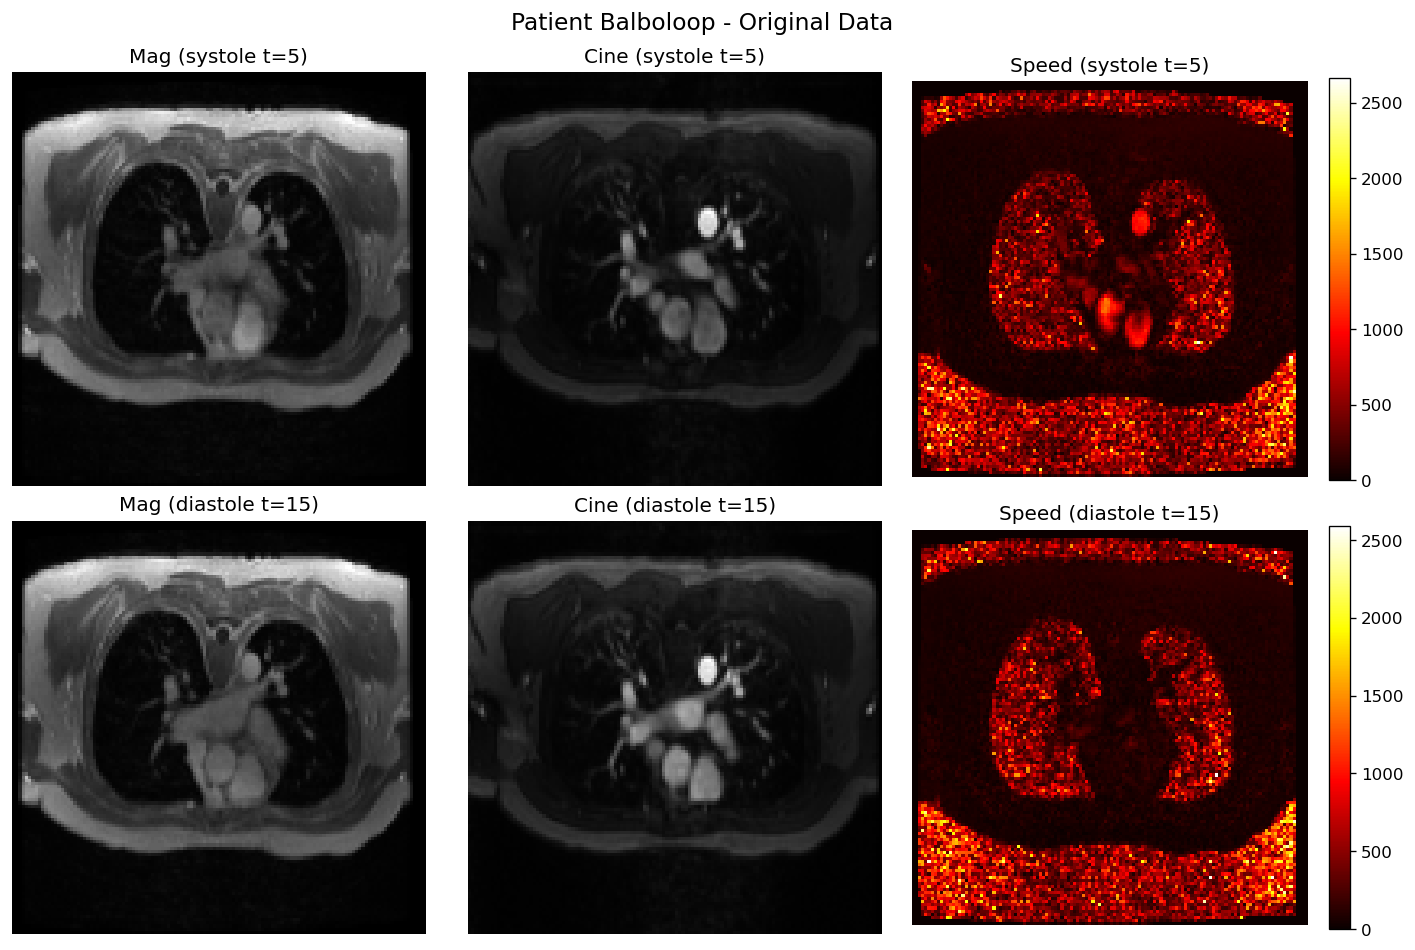

In [27]:
AX_SLICE = mag_sys.shape[-1] // 2  # mid axial slice

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 0].set_title(f'Mag (systole t={SYSTOLIC_TP})')
axes[0, 1].imshow(cine_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 1].set_title(f'Cine (systole t={SYSTOLIC_TP})')
im0 = axes[0, 2].imshow(speed_sys[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[0, 2].set_title(f'Speed (systole t={SYSTOLIC_TP})')
plt.colorbar(im0, ax=axes[0, 2], fraction=0.046)

axes[1, 0].imshow(mag_dia[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 0].set_title(f'Mag (diastole t={DIASTOLIC_TP})')
axes[1, 1].imshow(cine_dia[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 1].set_title(f'Cine (diastole t={DIASTOLIC_TP})')
im1 = axes[1, 2].imshow(speed_dia[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[1, 2].set_title(f'Speed (diastole t={DIASTOLIC_TP})')
plt.colorbar(im1, ax=axes[1, 2], fraction=0.046)

for ax in axes.flat:
    ax.axis('off')
plt.suptitle(f'Patient {PATIENT_ID} - Original Data', fontsize=14)
plt.tight_layout()
plt.show()

---
## 2. Sphere Inversion at Full FOV Scale

Adapt the existing patch-level sphere inversion for the full 128x128x64 volume.
Two variants:
- **Single large sphere**: one sphere with radius 20-60, random placement
- **Multiple smaller spheres**: 3-7 spheres with radius 10-30, scattered randomly

In [28]:
def apply_single_sphere_inversion(
    mag: torch.Tensor,
    radius_range=(20, 60),
    alpha=1.0,
    falloff_fraction=0.3,
) -> torch.Tensor:
    """Apply a single sphere inversion to a full FOV volume.

    Center is placed uniformly at random within the volume.
    """
    _, D, H, W = mag.shape
    center = (
        random.uniform(0, D),
        random.uniform(0, H),
        random.uniform(0, W),
    )
    radius = random.uniform(*radius_range)
    mask = _sphere_mask(D, H, W, center, radius, falloff_fraction, mag.device)
    inverted = 1.0 - mag
    return mag * (1 - mask * alpha) + inverted * (mask * alpha), mask


def apply_multi_sphere_inversion(
    mag: torch.Tensor,
    num_spheres_range=(3, 7),
    radius_range=(10, 30),
    alpha=1.0,
    falloff_fraction=0.3,
) -> torch.Tensor:
    """Apply multiple sphere inversions scattered randomly across the volume."""
    _, D, H, W = mag.shape
    n = random.randint(*num_spheres_range)
    combined_mask = torch.zeros(1, D, H, W, device=mag.device)
    for _ in range(n):
        center = (
            random.uniform(0, D),
            random.uniform(0, H),
            random.uniform(0, W),
        )
        radius = random.uniform(*radius_range)
        m = _sphere_mask(D, H, W, center, radius, falloff_fraction, mag.device)
        combined_mask = torch.clamp(combined_mask + m, 0, 1)
    inverted = 1.0 - mag
    result = mag * (1 - combined_mask * alpha) + inverted * (combined_mask * alpha)
    return result, combined_mask


def _sphere_mask(D, H, W, center, radius, falloff_fraction, device):
    """Create a smooth sphere mask with cosine falloff."""
    d = torch.arange(D, dtype=torch.float32, device=device)
    h = torch.arange(H, dtype=torch.float32, device=device)
    w = torch.arange(W, dtype=torch.float32, device=device)
    dg, hg, wg = torch.meshgrid(d, h, w, indexing='ij')
    dist = torch.sqrt(
        (dg - center[0])**2 + (hg - center[1])**2 + (wg - center[2])**2
    )
    falloff_width = radius * falloff_fraction
    inner_radius = radius - falloff_width
    normalised = torch.clamp((dist - inner_radius) / (falloff_width + 1e-8), 0, 1)
    mask = 0.5 * (1 + torch.cos(math.pi * normalised))
    mask = torch.where(dist < inner_radius, torch.ones_like(mask), mask)
    return mask.unsqueeze(0)

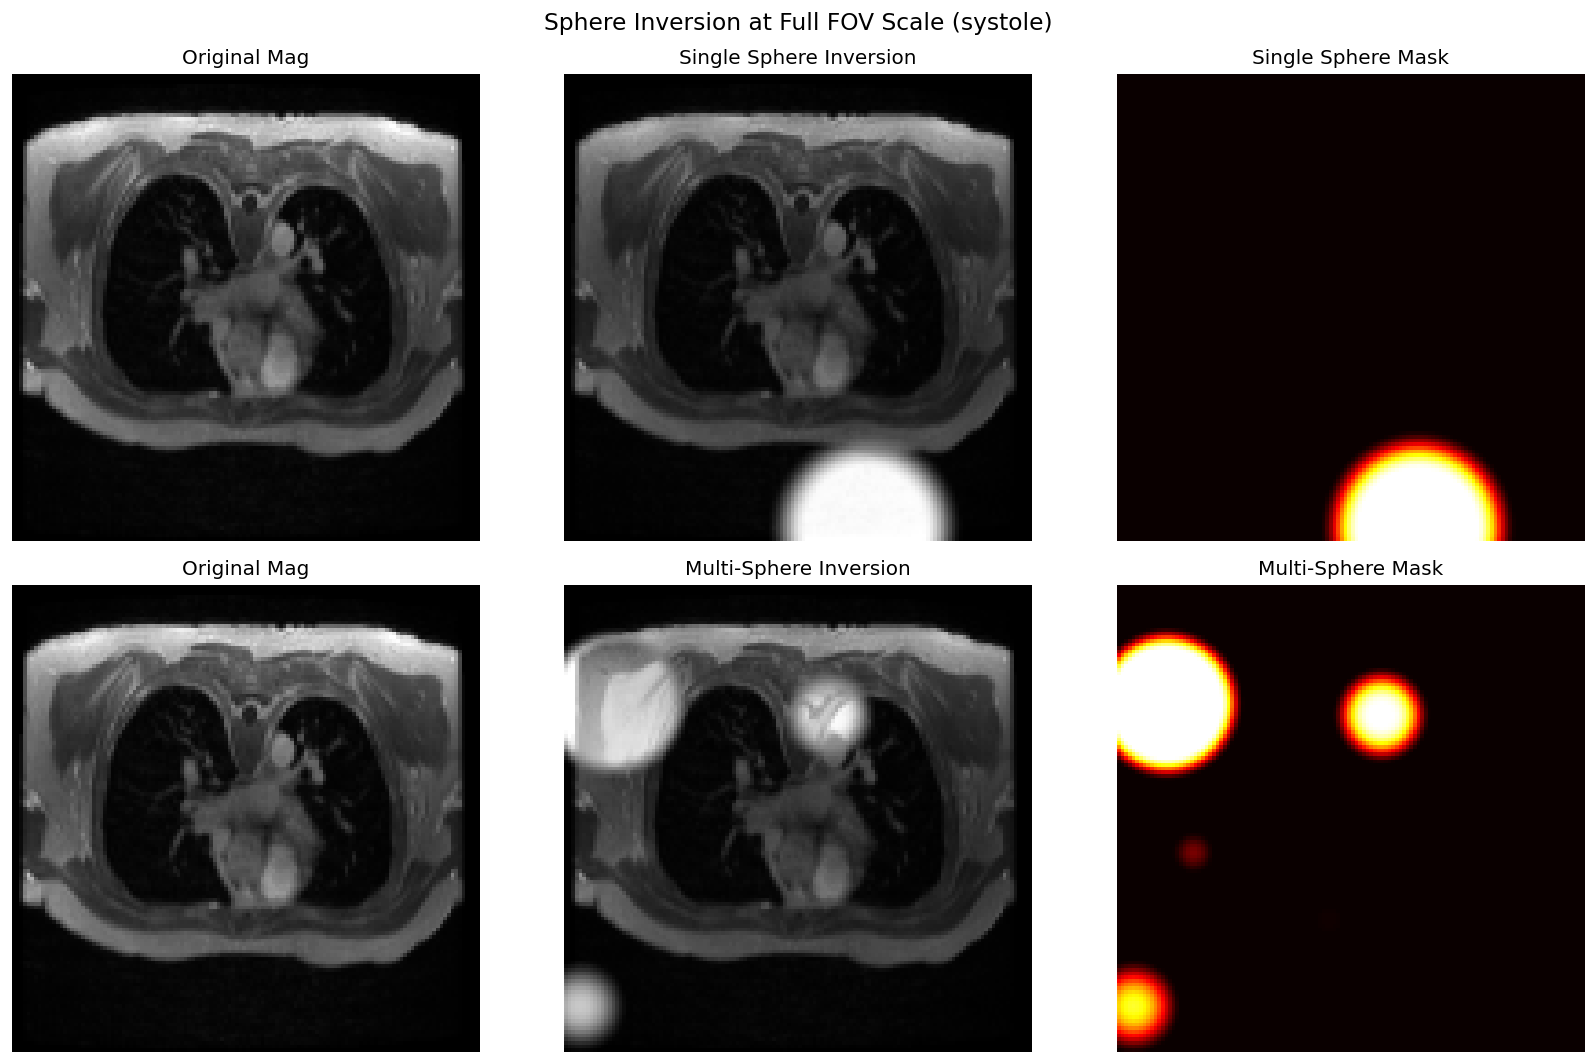

In [29]:
random.seed(42)
inv_single, mask_single = apply_single_sphere_inversion(
    mag_sys, radius_range=(25, 50), alpha=1.0
)
random.seed(42)
inv_multi, mask_multi = apply_multi_sphere_inversion(
    mag_sys, num_spheres_range=(4, 6), radius_range=(12, 28), alpha=1.0
)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes[0, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 0].set_title('Original Mag')
axes[0, 1].imshow(inv_single[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[0, 1].set_title('Single Sphere Inversion')
axes[0, 2].imshow(mask_single[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[0, 2].set_title('Single Sphere Mask')

axes[1, 0].imshow(mag_sys[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 0].set_title('Original Mag')
axes[1, 1].imshow(inv_multi[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
axes[1, 1].set_title('Multi-Sphere Inversion')
axes[1, 2].imshow(mask_multi[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[1, 2].set_title('Multi-Sphere Mask')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Sphere Inversion at Full FOV Scale (systole)', fontsize=14)
plt.tight_layout()
plt.show()

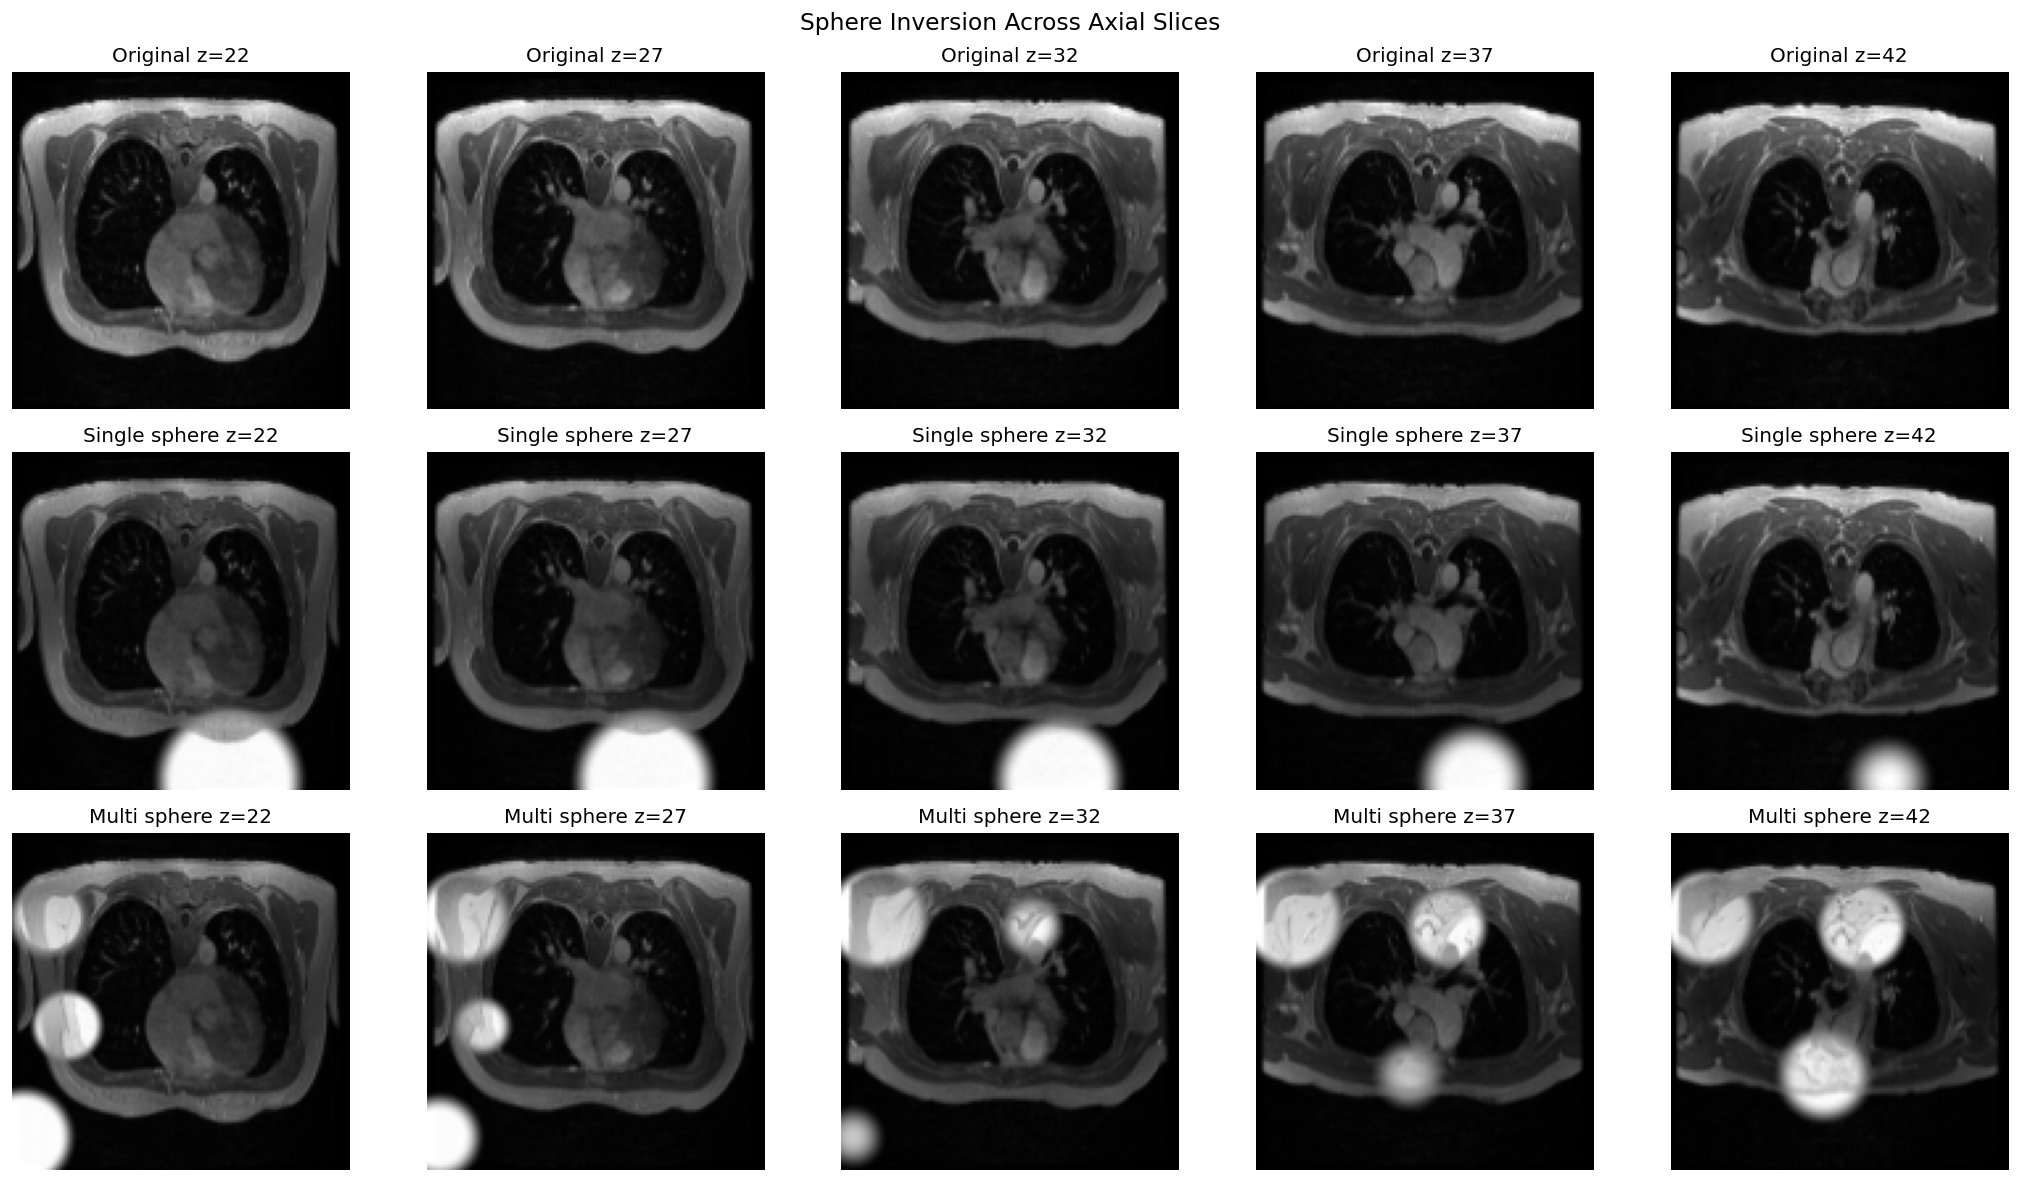

In [30]:
# Show across multiple axial slices to see 3D coverage
slices = [AX_SLICE - 10, AX_SLICE - 5, AX_SLICE, AX_SLICE + 5, AX_SLICE + 10]
slices = [s for s in slices if 0 <= s < mag_sys.shape[-1]]

fig, axes = plt.subplots(3, len(slices), figsize=(3.5 * len(slices), 10))
for j, s in enumerate(slices):
    axes[0, j].imshow(mag_sys[0, :, :, s].T, cmap='gray', origin='lower')
    axes[0, j].set_title(f'Original z={s}')
    axes[1, j].imshow(inv_single[0, :, :, s].T, cmap='gray', origin='lower')
    axes[1, j].set_title(f'Single sphere z={s}')
    axes[2, j].imshow(inv_multi[0, :, :, s].T, cmap='gray', origin='lower')
    axes[2, j].set_title(f'Multi sphere z={s}')
for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Sphere Inversion Across Axial Slices', fontsize=14)
plt.tight_layout()
plt.show()

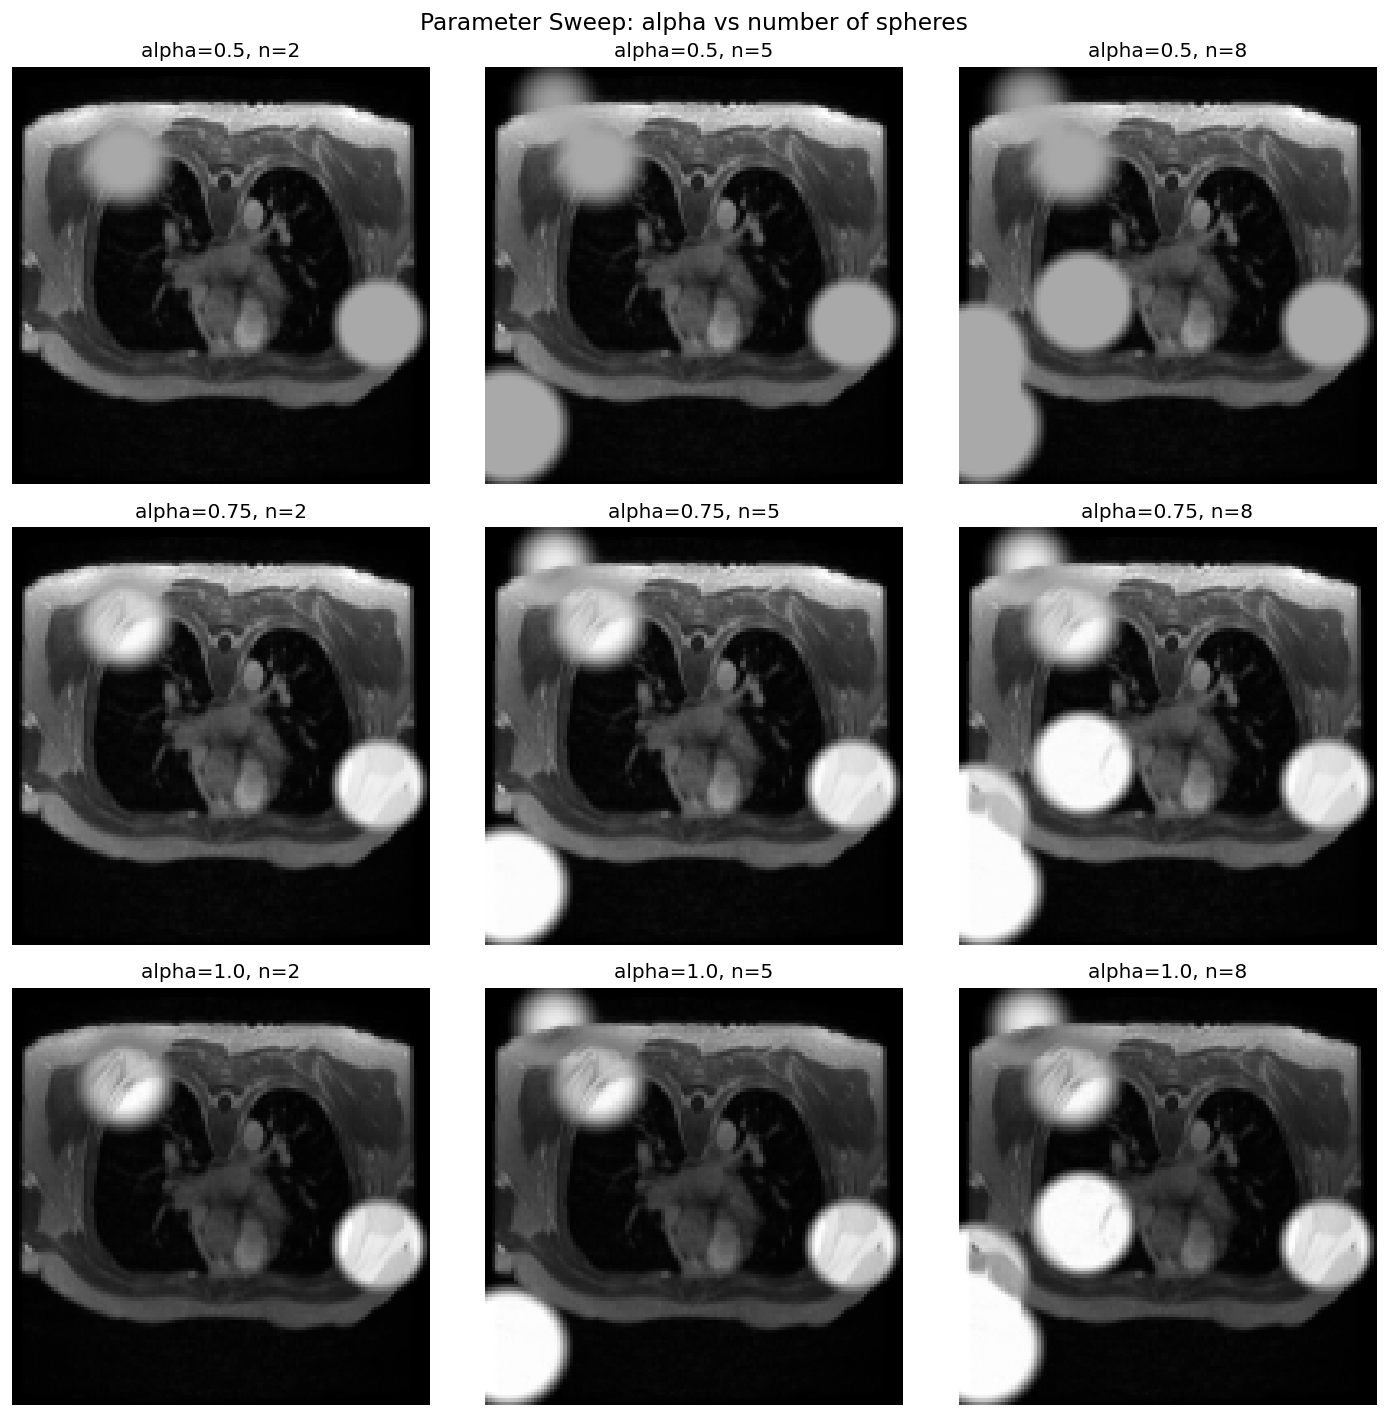

In [31]:
# Parameter sweep: vary alpha and number of spheres
alphas = [0.5, 0.75, 1.0]
n_spheres_list = [2, 5, 8]

fig, axes = plt.subplots(len(alphas), len(n_spheres_list), figsize=(12, 12))
for i, alpha in enumerate(alphas):
    for j, n in enumerate(n_spheres_list):
        random.seed(123)
        result, _ = apply_multi_sphere_inversion(
            mag_sys, num_spheres_range=(n, n), radius_range=(12, 25), alpha=alpha
        )
        axes[i, j].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
        axes[i, j].set_title(f'alpha={alpha}, n={n}')
        axes[i, j].axis('off')
plt.suptitle('Parameter Sweep: alpha vs number of spheres', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Per-Timepoint Speed-Guided Inversion

Use the speed field from the current timepoint's velocity to guide where
contrast inversion happens. Two sub-approaches:
- **Hard threshold**: binarise speed above a threshold, invert within mask
- **Soft alpha**: use normalised speed directly as a spatially-varying alpha

In [32]:
AIR_THRESHOLD = 0.05  # voxels below this mag value are considered air


def _body_mask(mag: torch.Tensor, air_threshold: float = AIR_THRESHOLD) -> torch.Tensor:
    """Binary mask that is 1 inside tissue and 0 in air."""
    return (mag > air_threshold).float()


def speed_threshold_inversion(
    mag: torch.Tensor,
    speed: torch.Tensor,
    threshold_fraction: float = 0.15,
    alpha: float = 1.0,
    smooth_sigma: float = 2.0,
) -> tuple:
    """Invert mag where speed exceeds a fraction of its max.

    Air voxels (mag < AIR_THRESHOLD) are left untouched.
    """
    threshold = speed.max() * threshold_fraction
    mask = (speed > threshold).float()

    if smooth_sigma > 0:
        mask = _gaussian_smooth_3d(mask, sigma=smooth_sigma)

    mask = mask * _body_mask(mag)

    inverted = 1.0 - mag
    result = mag * (1 - mask * alpha) + inverted * (mask * alpha)
    return result, mask


def speed_soft_alpha_inversion(
    mag: torch.Tensor,
    speed: torch.Tensor,
    speed_cap: float = None,
    alpha_scale: float = 1.0,
    smooth_sigma: float = 2.0,
) -> tuple:
    """Inversion strength is proportional to normalised speed.

    Air voxels (mag < AIR_THRESHOLD) are left untouched.
    """
    if speed_cap is None:
        speed_cap = speed.max()
    alpha_map = (speed / (speed_cap + 1e-8)).clamp(0, 1) * alpha_scale

    if smooth_sigma > 0:
        alpha_map = _gaussian_smooth_3d(alpha_map, sigma=smooth_sigma)

    alpha_map = alpha_map * _body_mask(mag)

    inverted = 1.0 - mag
    result = mag * (1 - alpha_map) + inverted * alpha_map
    return result, alpha_map


def _gaussian_smooth_3d(tensor, sigma=2.0):
    """Simple 3D Gaussian smoothing using separable 1D convolutions."""
    ks = int(6 * sigma + 1)
    if ks % 2 == 0:
        ks += 1
    x = torch.arange(ks, dtype=torch.float32, device=tensor.device) - ks // 2
    kernel_1d = torch.exp(-0.5 * (x / sigma) ** 2)
    kernel_1d = kernel_1d / kernel_1d.sum()

    t = tensor.unsqueeze(0) if tensor.dim() == 4 else tensor
    pad = ks // 2

    # F.pad order is (W_left, W_right, H_left, H_right, D_left, D_right)
    pad_configs = {
        2: [0, 0, 0, 0, pad, pad],  # pad D only
        3: [0, 0, pad, pad, 0, 0],  # pad H only
        4: [pad, pad, 0, 0, 0, 0],  # pad W only
    }

    for dim in [2, 3, 4]:
        t = torch.nn.functional.pad(t, pad_configs[dim], mode='replicate')
        weight = torch.zeros(1, 1, ks if dim == 2 else 1,
                             ks if dim == 3 else 1,
                             ks if dim == 4 else 1, device=tensor.device)
        if dim == 2:
            weight[0, 0, :, 0, 0] = kernel_1d
        elif dim == 3:
            weight[0, 0, 0, :, 0] = kernel_1d
        else:
            weight[0, 0, 0, 0, :] = kernel_1d
        t = torch.nn.functional.conv3d(t, weight, padding=0)

    return t.squeeze(0) if tensor.dim() == 4 else t

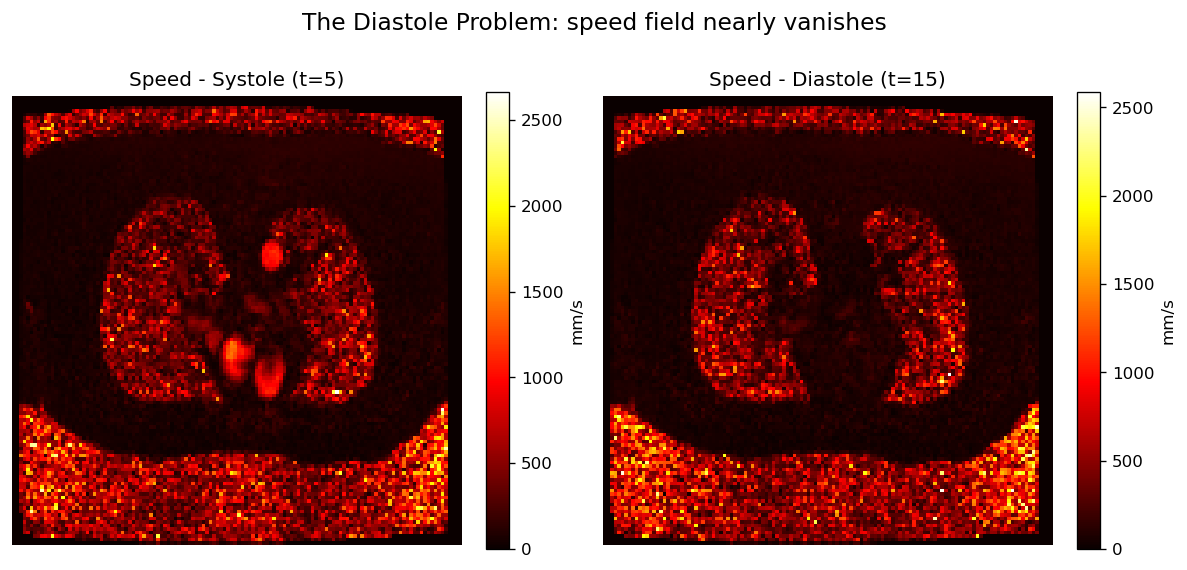

Systole speed: max=4056.9, mean=334.5, >15% max: 18.6% of voxels
Diastole speed: max=4008.8, mean=329.4, >15% max: 18.6% of voxels


In [33]:
# Visualise speed fields: systole vs diastole
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
im0 = axes[0].imshow(speed_sys[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[0].set_title(f'Speed - Systole (t={SYSTOLIC_TP})')
plt.colorbar(im0, ax=axes[0], fraction=0.046, label='mm/s')
im1 = axes[1].imshow(speed_dia[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[1].set_title(f'Speed - Diastole (t={DIASTOLIC_TP})')
plt.colorbar(im1, ax=axes[1], fraction=0.046, label='mm/s')
for ax in axes:
    ax.axis('off')
plt.suptitle('The Diastole Problem: speed field nearly vanishes', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Systole speed: max={speed_sys.max():.1f}, mean={speed_sys.mean():.1f}, "
      f">15% max: {(speed_sys > 0.15*speed_sys.max()).float().mean()*100:.1f}% of voxels")
print(f"Diastole speed: max={speed_dia.max():.1f}, mean={speed_dia.mean():.1f}, "
      f">15% max: {(speed_dia > 0.15*speed_dia.max()).float().mean()*100:.1f}% of voxels")

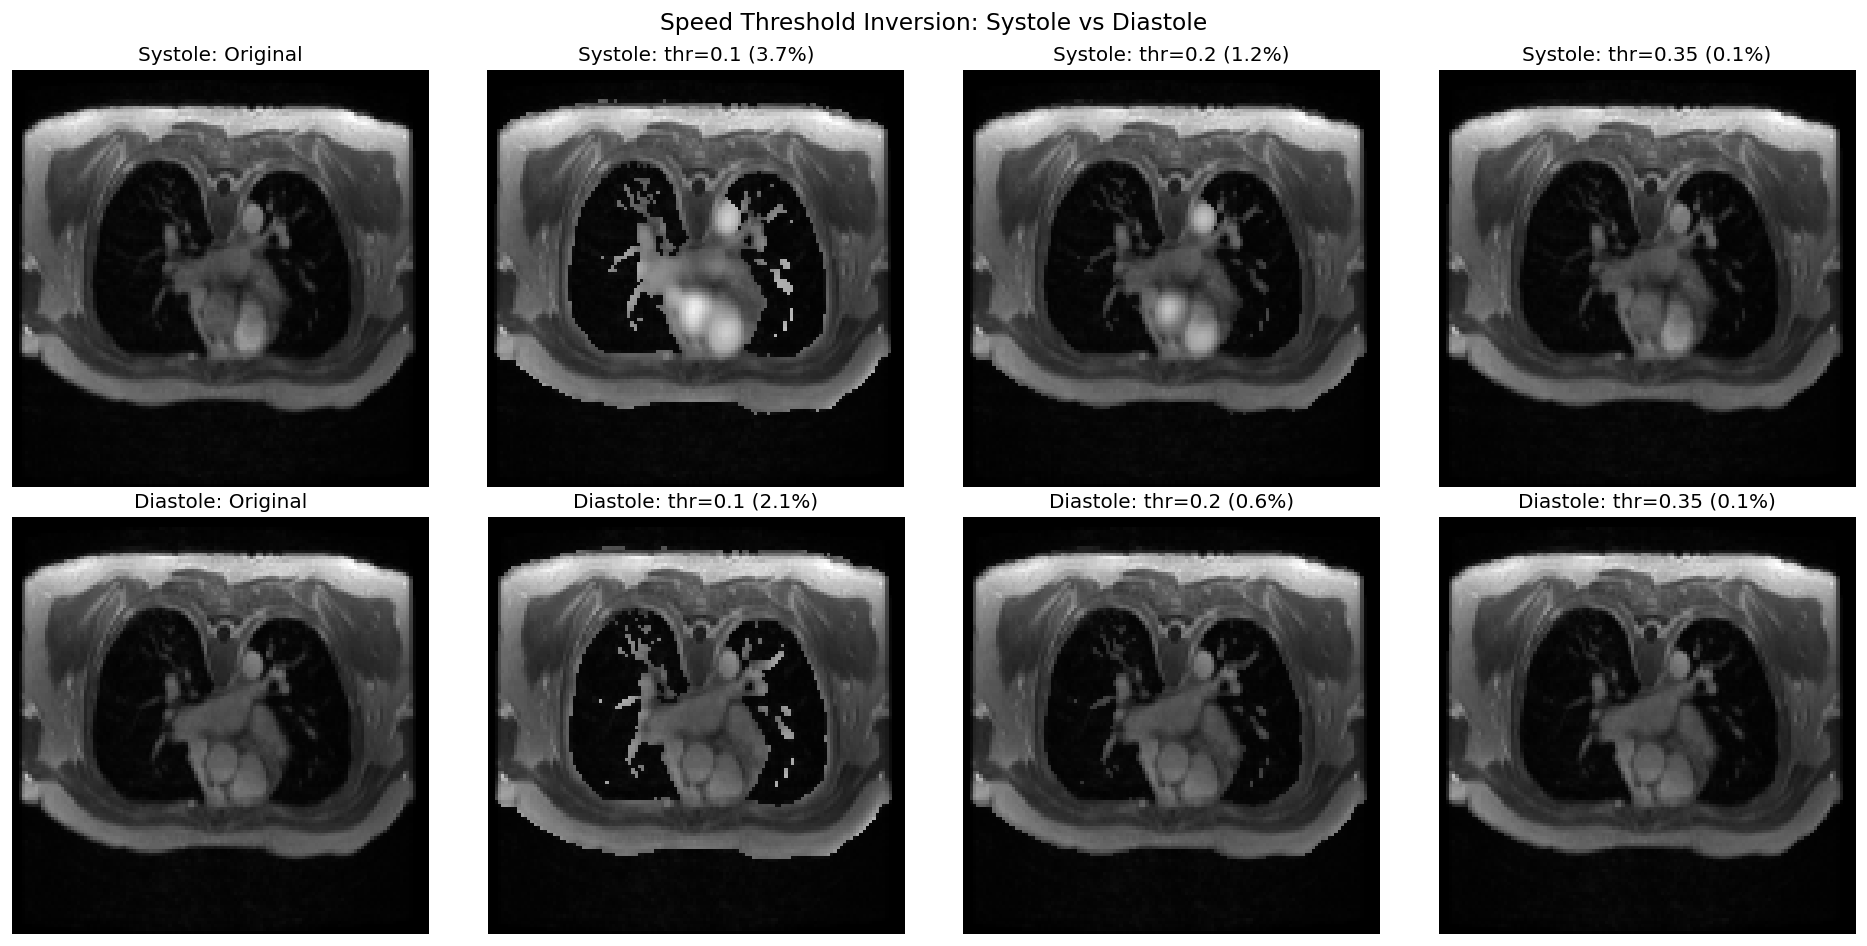

In [34]:
# Speed threshold inversion - compare systole vs diastole
thresholds = [0.10, 0.20, 0.35]

fig, axes = plt.subplots(2, len(thresholds) + 1, figsize=(4 * (len(thresholds) + 1), 8))

for row, (mag, speed, label) in enumerate([
    (mag_sys, speed_sys, 'Systole'),
    (mag_dia, speed_dia, 'Diastole'),
]):
    axes[row, 0].imshow(mag[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'{label}: Original')
    for j, thr in enumerate(thresholds):
        result, mask = speed_threshold_inversion(mag, speed, threshold_fraction=thr)
        axes[row, j + 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
        pct = mask[0, :, :, AX_SLICE].mean().item() * 100
        axes[row, j + 1].set_title(f'{label}: thr={thr} ({pct:.1f}%)')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Speed Threshold Inversion: Systole vs Diastole', fontsize=14)
plt.tight_layout()
plt.show()

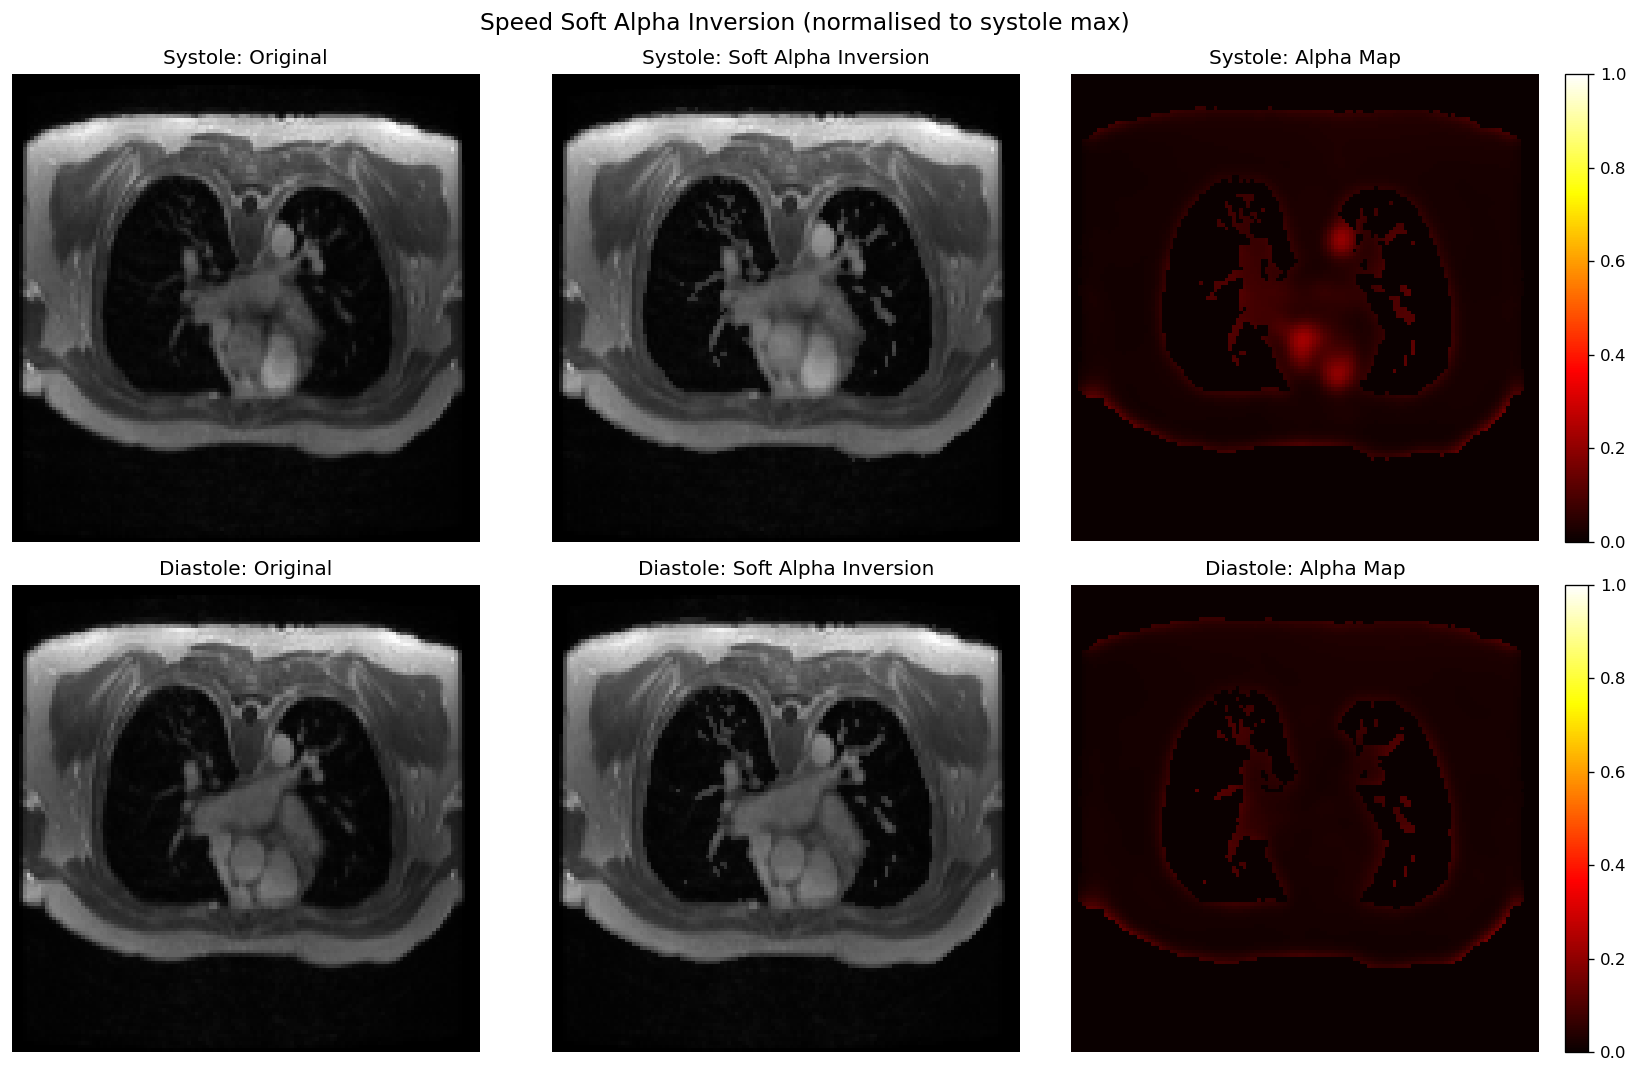

In [35]:
# Soft alpha inversion - speed as continuous alpha map
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for row, (mag, speed, label) in enumerate([
    (mag_sys, speed_sys, 'Systole'),
    (mag_dia, speed_dia, 'Diastole'),
]):
    axes[row, 0].imshow(mag[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'{label}: Original')

    result, alpha_map = speed_soft_alpha_inversion(
        mag, speed, speed_cap=speed_sys.max(), alpha_scale=1.0
    )
    axes[row, 1].imshow(result[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 1].set_title(f'{label}: Soft Alpha Inversion')

    im = axes[row, 2].imshow(alpha_map[0, :, :, AX_SLICE].T, cmap='hot', origin='lower',
                              vmin=0, vmax=1)
    axes[row, 2].set_title(f'{label}: Alpha Map')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Speed Soft Alpha Inversion (normalised to systole max)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Aggregate Speed-Guided Inversion

Compute max speed across ALL timepoints for this patient. This gives a
timepoint-independent vascular mask that captures everywhere flow occurs
at any point in the cardiac cycle.

In [36]:
# Load velocity for all timepoints and compute max speed
all_speeds = []
for t in range(NUM_TIMEPOINTS):
    vels = []
    for comp in ('vx', 'vy', 'vz'):
        path = DATA_ROOT / f"4d_flow_{comp}" / f"4d_flow_{comp}_{PATIENT_ID}_frame_{t:02d}.nii.gz"
        vel = torch.from_numpy(nib.load(str(path)).get_fdata()).float().unsqueeze(0)
        vels.append(vel)
    speed_t = compute_speed(*vels)
    all_speeds.append(speed_t)

max_speed = torch.stack(all_speeds).max(dim=0).values  # [1, D, H, W]
mean_speed = torch.stack(all_speeds).mean(dim=0)       # [1, D, H, W]

print(f"Max speed over time: shape={max_speed.shape}, "
      f"range=[{max_speed.min():.1f}, {max_speed.max():.1f}]")
print(f"Mean speed over time: range=[{mean_speed.min():.1f}, {mean_speed.max():.1f}]")

Max speed over time: shape=torch.Size([1, 128, 128, 64]), range=[0.0, 4217.8]
Mean speed over time: range=[0.0, 3082.8]


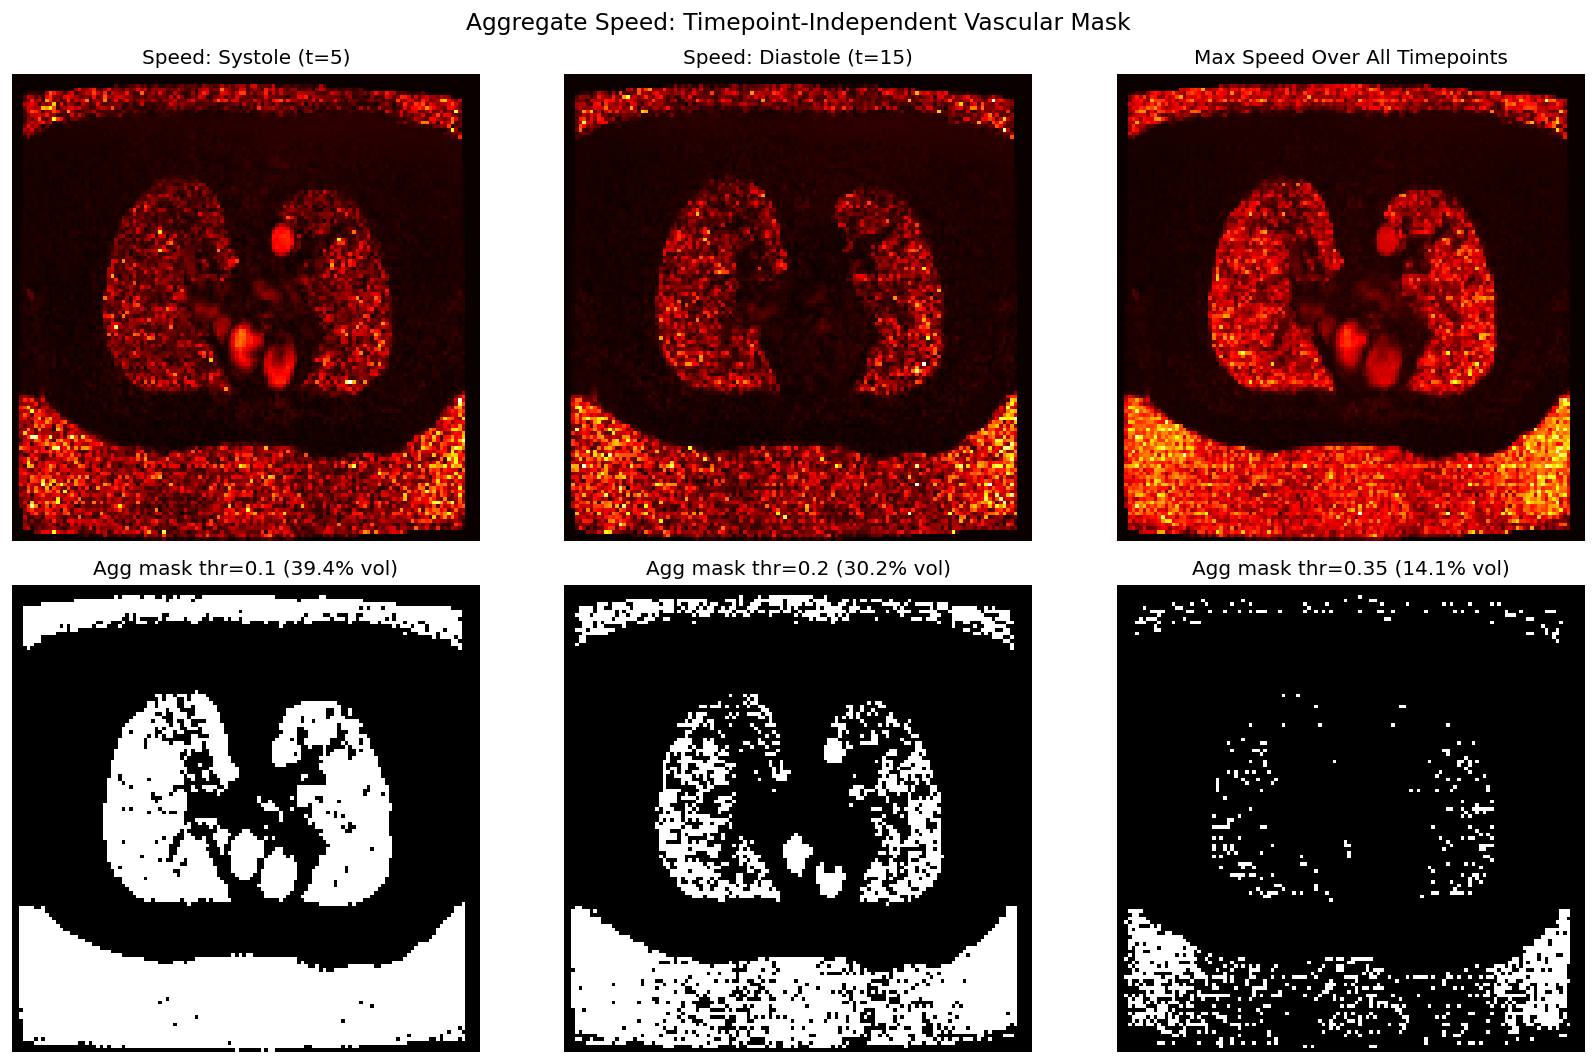

In [37]:
# Compare per-timepoint speed vs aggregate speed
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

axes[0, 0].imshow(speed_sys[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[0, 0].set_title(f'Speed: Systole (t={SYSTOLIC_TP})')
axes[0, 1].imshow(speed_dia[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[0, 1].set_title(f'Speed: Diastole (t={DIASTOLIC_TP})')
axes[0, 2].imshow(max_speed[0, :, :, AX_SLICE].T, cmap='hot', origin='lower')
axes[0, 2].set_title('Max Speed Over All Timepoints')

# Threshold the aggregate speed to show the vascular mask it produces
for j, thr_frac in enumerate([0.10, 0.20, 0.35]):
    thr = max_speed.max() * thr_frac
    mask = (max_speed > thr).float()
    pct = mask.mean().item() * 100
    axes[1, j].imshow(mask[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[1, j].set_title(f'Agg mask thr={thr_frac} ({pct:.1f}% vol)')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Aggregate Speed: Timepoint-Independent Vascular Mask', fontsize=14)
plt.tight_layout()
plt.show()

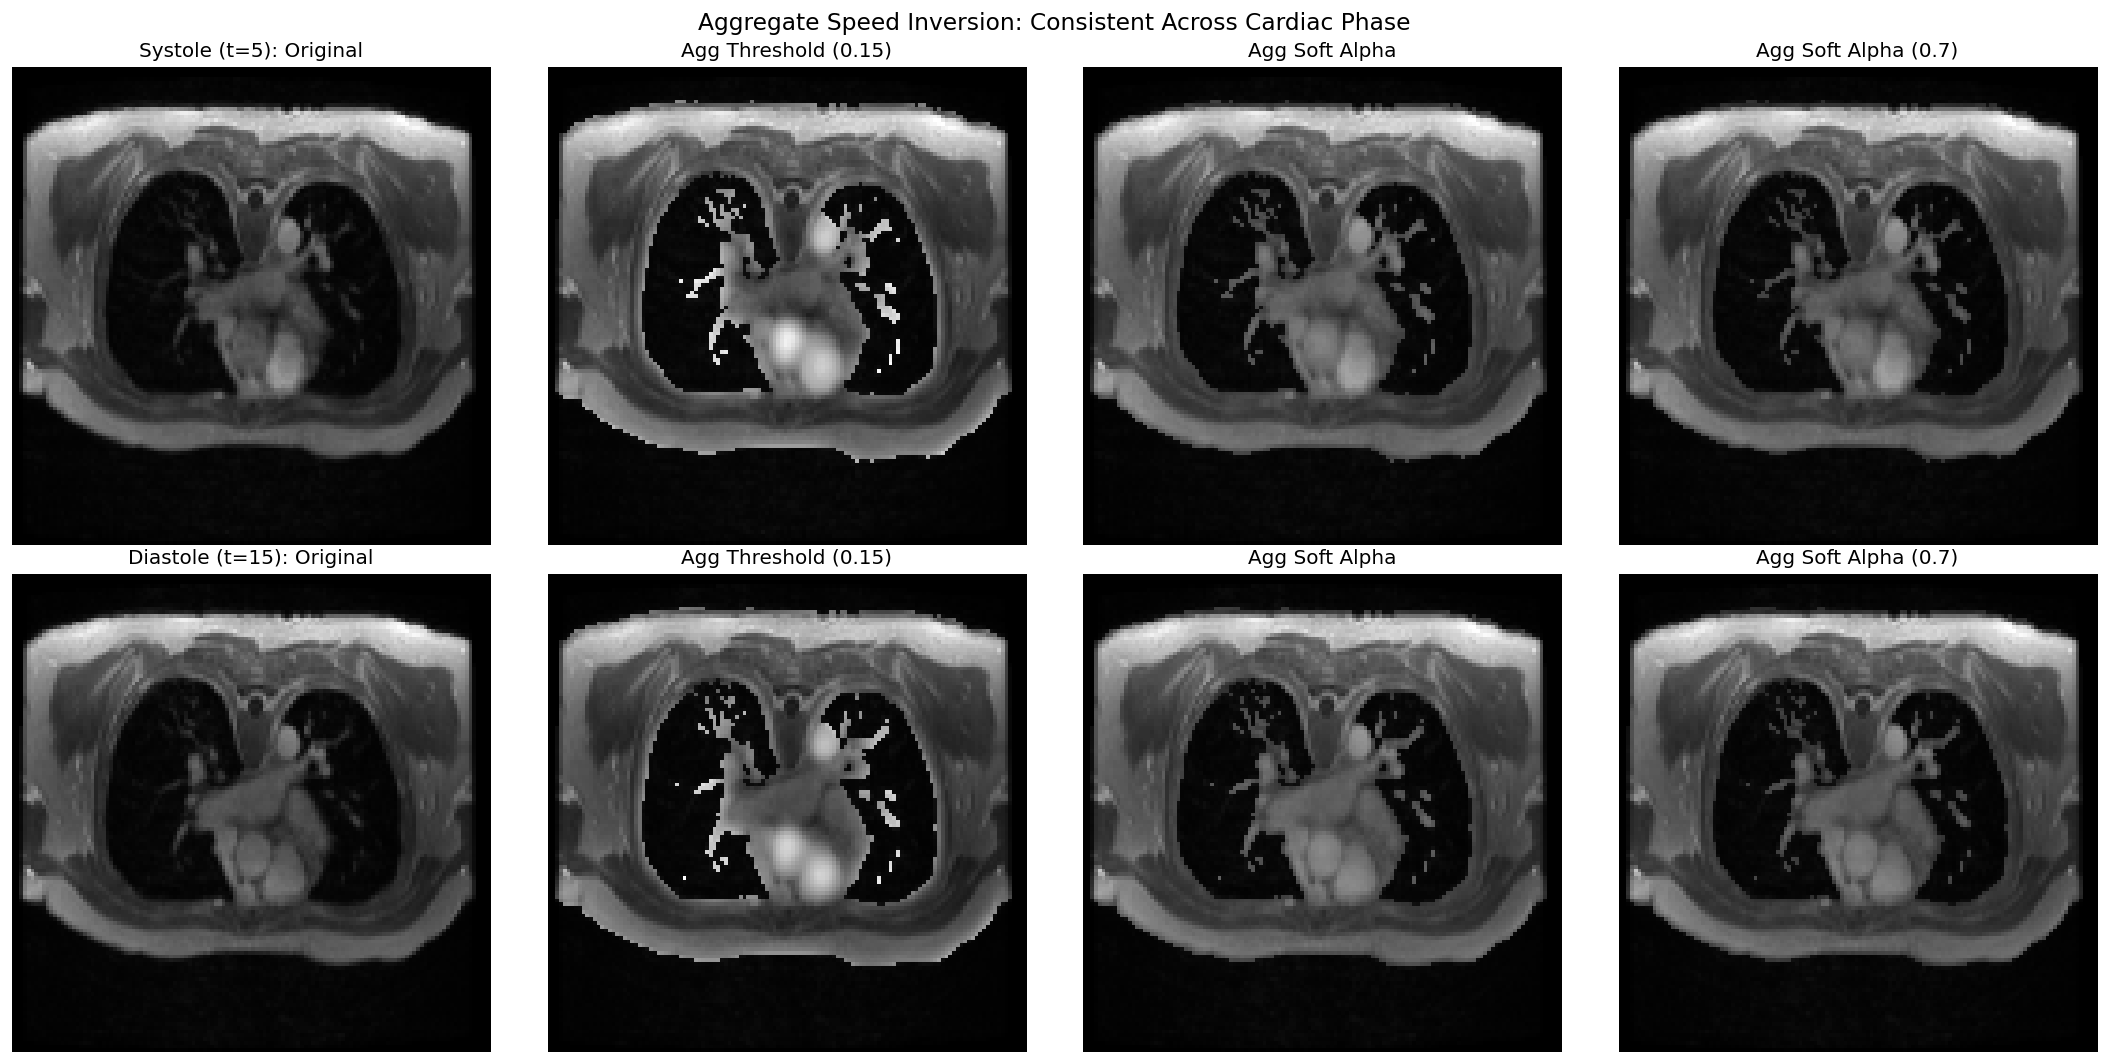

In [38]:
# Apply aggregate speed inversion to both systolic and diastolic mag
# Using both threshold and soft alpha approaches
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row, (mag, label) in enumerate([
    (mag_sys, f'Systole (t={SYSTOLIC_TP})'),
    (mag_dia, f'Diastole (t={DIASTOLIC_TP})'),
]):
    axes[row, 0].imshow(mag[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'{label}: Original')

    # Hard threshold on aggregate speed
    res_thr, mask_thr = speed_threshold_inversion(
        mag, max_speed, threshold_fraction=0.15, alpha=1.0
    )
    axes[row, 1].imshow(res_thr[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 1].set_title(f'Agg Threshold (0.15)')

    # Soft alpha on aggregate speed
    res_soft, alpha_soft = speed_soft_alpha_inversion(
        mag, max_speed, speed_cap=max_speed.max(), alpha_scale=1.0
    )
    axes[row, 2].imshow(res_soft[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 2].set_title('Agg Soft Alpha')

    # Soft alpha with lower scale
    res_soft07, _ = speed_soft_alpha_inversion(
        mag, max_speed, speed_cap=max_speed.max(), alpha_scale=0.7
    )
    axes[row, 3].imshow(res_soft07[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 3].set_title('Agg Soft Alpha (0.7)')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Aggregate Speed Inversion: Consistent Across Cardiac Phase', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Hybrid: Spheres + Speed Weighting

Combine spatial randomness (spheres) with anatomical targeting (speed).
Within each sphere, the inversion alpha is modulated by the local speed value,
so vessels get more strongly inverted than background tissue.

In [39]:
def apply_speed_weighted_sphere_inversion(
    mag: torch.Tensor,
    speed: torch.Tensor,
    num_spheres_range=(3, 7),
    radius_range=(12, 30),
    base_alpha=0.3,
    speed_alpha_scale=0.7,
    speed_cap=None,
    falloff_fraction=0.3,
) -> tuple:
    """Multi-sphere inversion with alpha modulated by speed.

    effective_alpha = base_alpha + speed_alpha_scale * normalised_speed
    so background gets mild inversion, vessels get strong inversion.
    """
    _, D, H, W = mag.shape
    if speed_cap is None:
        speed_cap = speed.max()
    norm_speed = (speed / (speed_cap + 1e-8)).clamp(0, 1)

    n = random.randint(*num_spheres_range)
    combined_mask = torch.zeros(1, D, H, W, device=mag.device)
    for _ in range(n):
        center = (random.uniform(0, D), random.uniform(0, H), random.uniform(0, W))
        radius = random.uniform(*radius_range)
        m = _sphere_mask(D, H, W, center, radius, falloff_fraction, mag.device)
        combined_mask = torch.clamp(combined_mask + m, 0, 1)

    alpha_map = combined_mask * (base_alpha + speed_alpha_scale * norm_speed)
    alpha_map = alpha_map.clamp(0, 1)
    alpha_map = alpha_map * _body_mask(mag)

    inverted = 1.0 - mag
    result = mag * (1 - alpha_map) + inverted * alpha_map
    return result, alpha_map, combined_mask

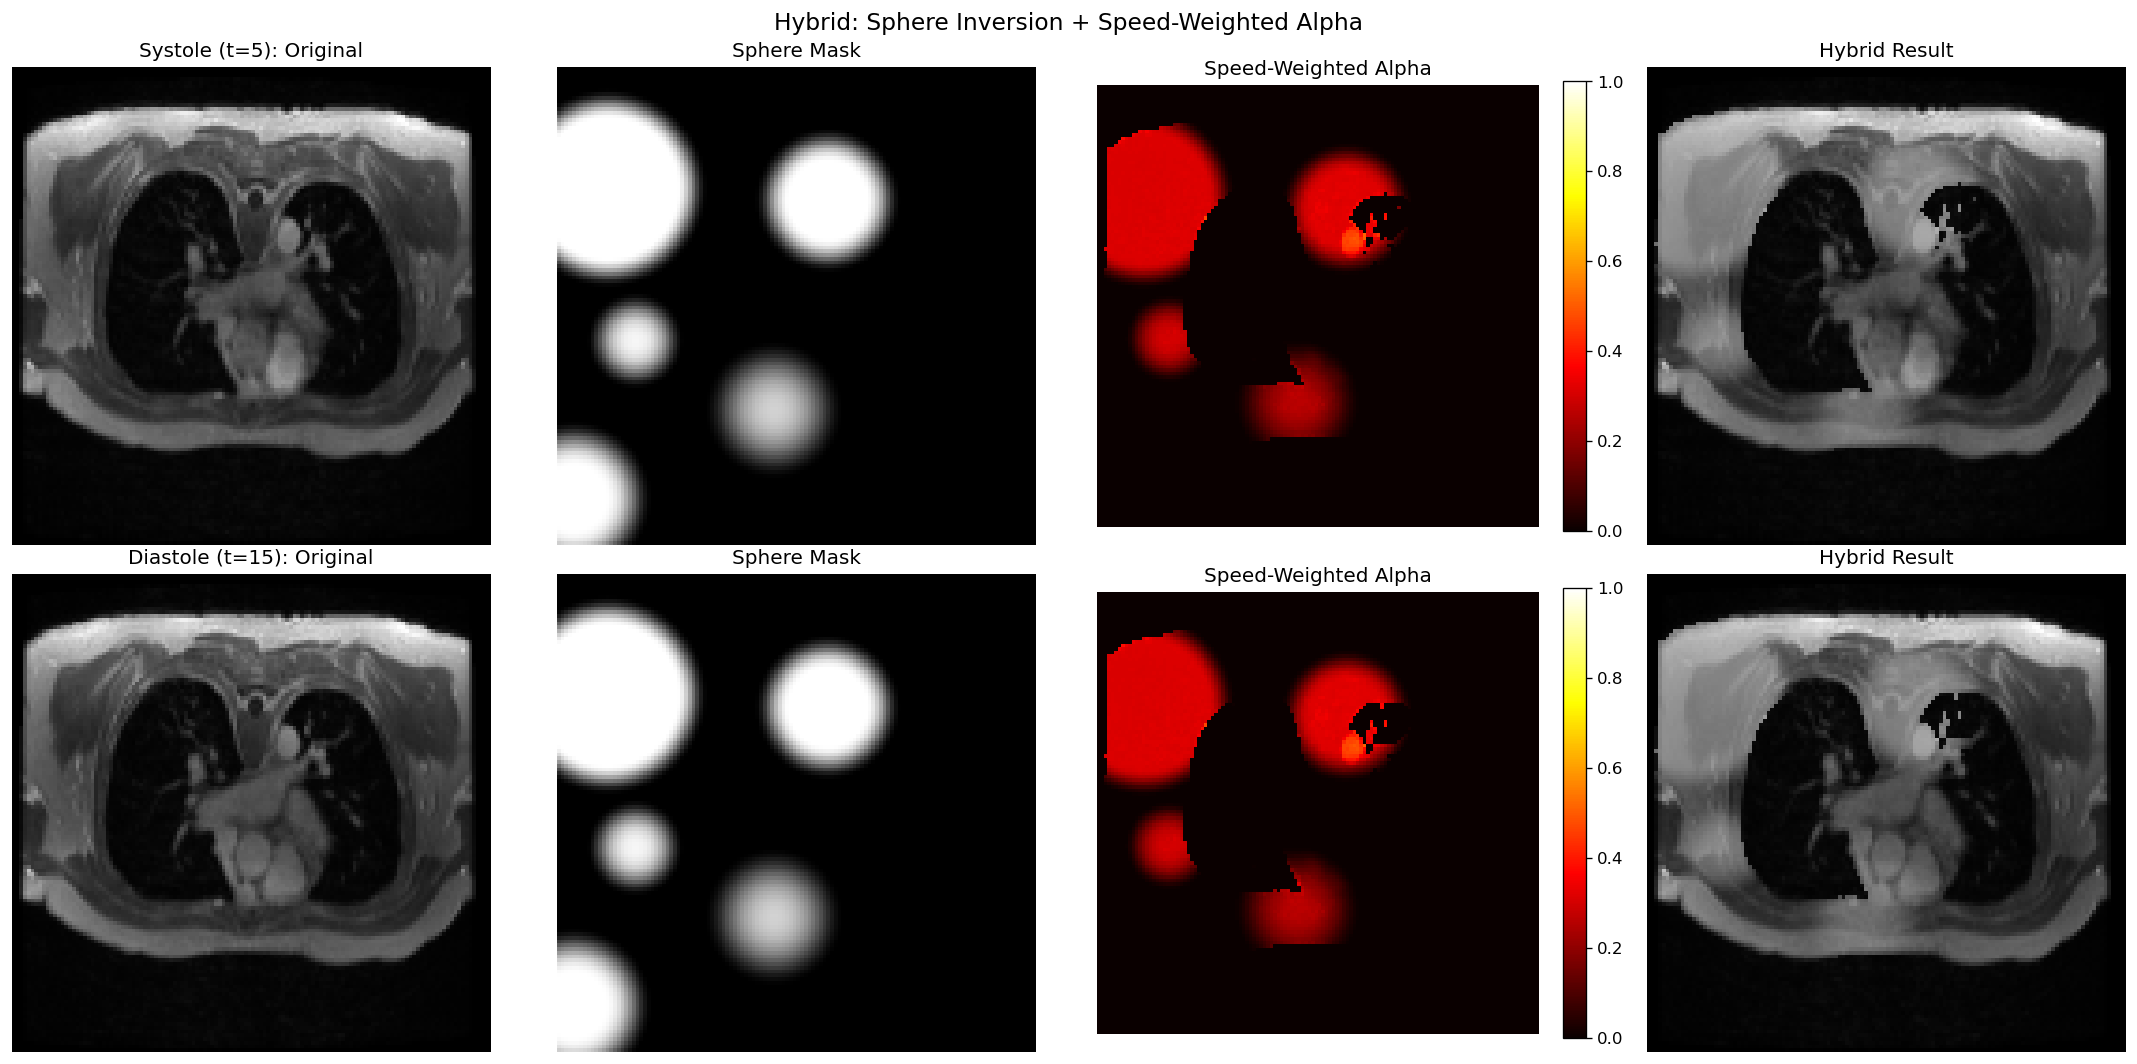

In [40]:
random.seed(42)
hybrid_sys, alpha_sys, smask_sys = apply_speed_weighted_sphere_inversion(
    mag_sys, max_speed, num_spheres_range=(4, 6), radius_range=(15, 35),
    base_alpha=0.3, speed_alpha_scale=0.7, speed_cap=max_speed.max()
)
random.seed(42)
hybrid_dia, alpha_dia, smask_dia = apply_speed_weighted_sphere_inversion(
    mag_dia, max_speed, num_spheres_range=(4, 6), radius_range=(15, 35),
    base_alpha=0.3, speed_alpha_scale=0.7, speed_cap=max_speed.max()
)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for row, (mag, res, amap, smask, label) in enumerate([
    (mag_sys, hybrid_sys, alpha_sys, smask_sys, f'Systole (t={SYSTOLIC_TP})'),
    (mag_dia, hybrid_dia, alpha_dia, smask_dia, f'Diastole (t={DIASTOLIC_TP})'),
]):
    axes[row, 0].imshow(mag[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 0].set_title(f'{label}: Original')
    axes[row, 1].imshow(smask[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 1].set_title('Sphere Mask')
    im = axes[row, 2].imshow(amap[0, :, :, AX_SLICE].T, cmap='hot', origin='lower',
                              vmin=0, vmax=1)
    axes[row, 2].set_title('Speed-Weighted Alpha')
    plt.colorbar(im, ax=axes[row, 2], fraction=0.046)
    axes[row, 3].imshow(res[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[row, 3].set_title('Hybrid Result')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Hybrid: Sphere Inversion + Speed-Weighted Alpha', fontsize=14)
plt.tight_layout()
plt.show()

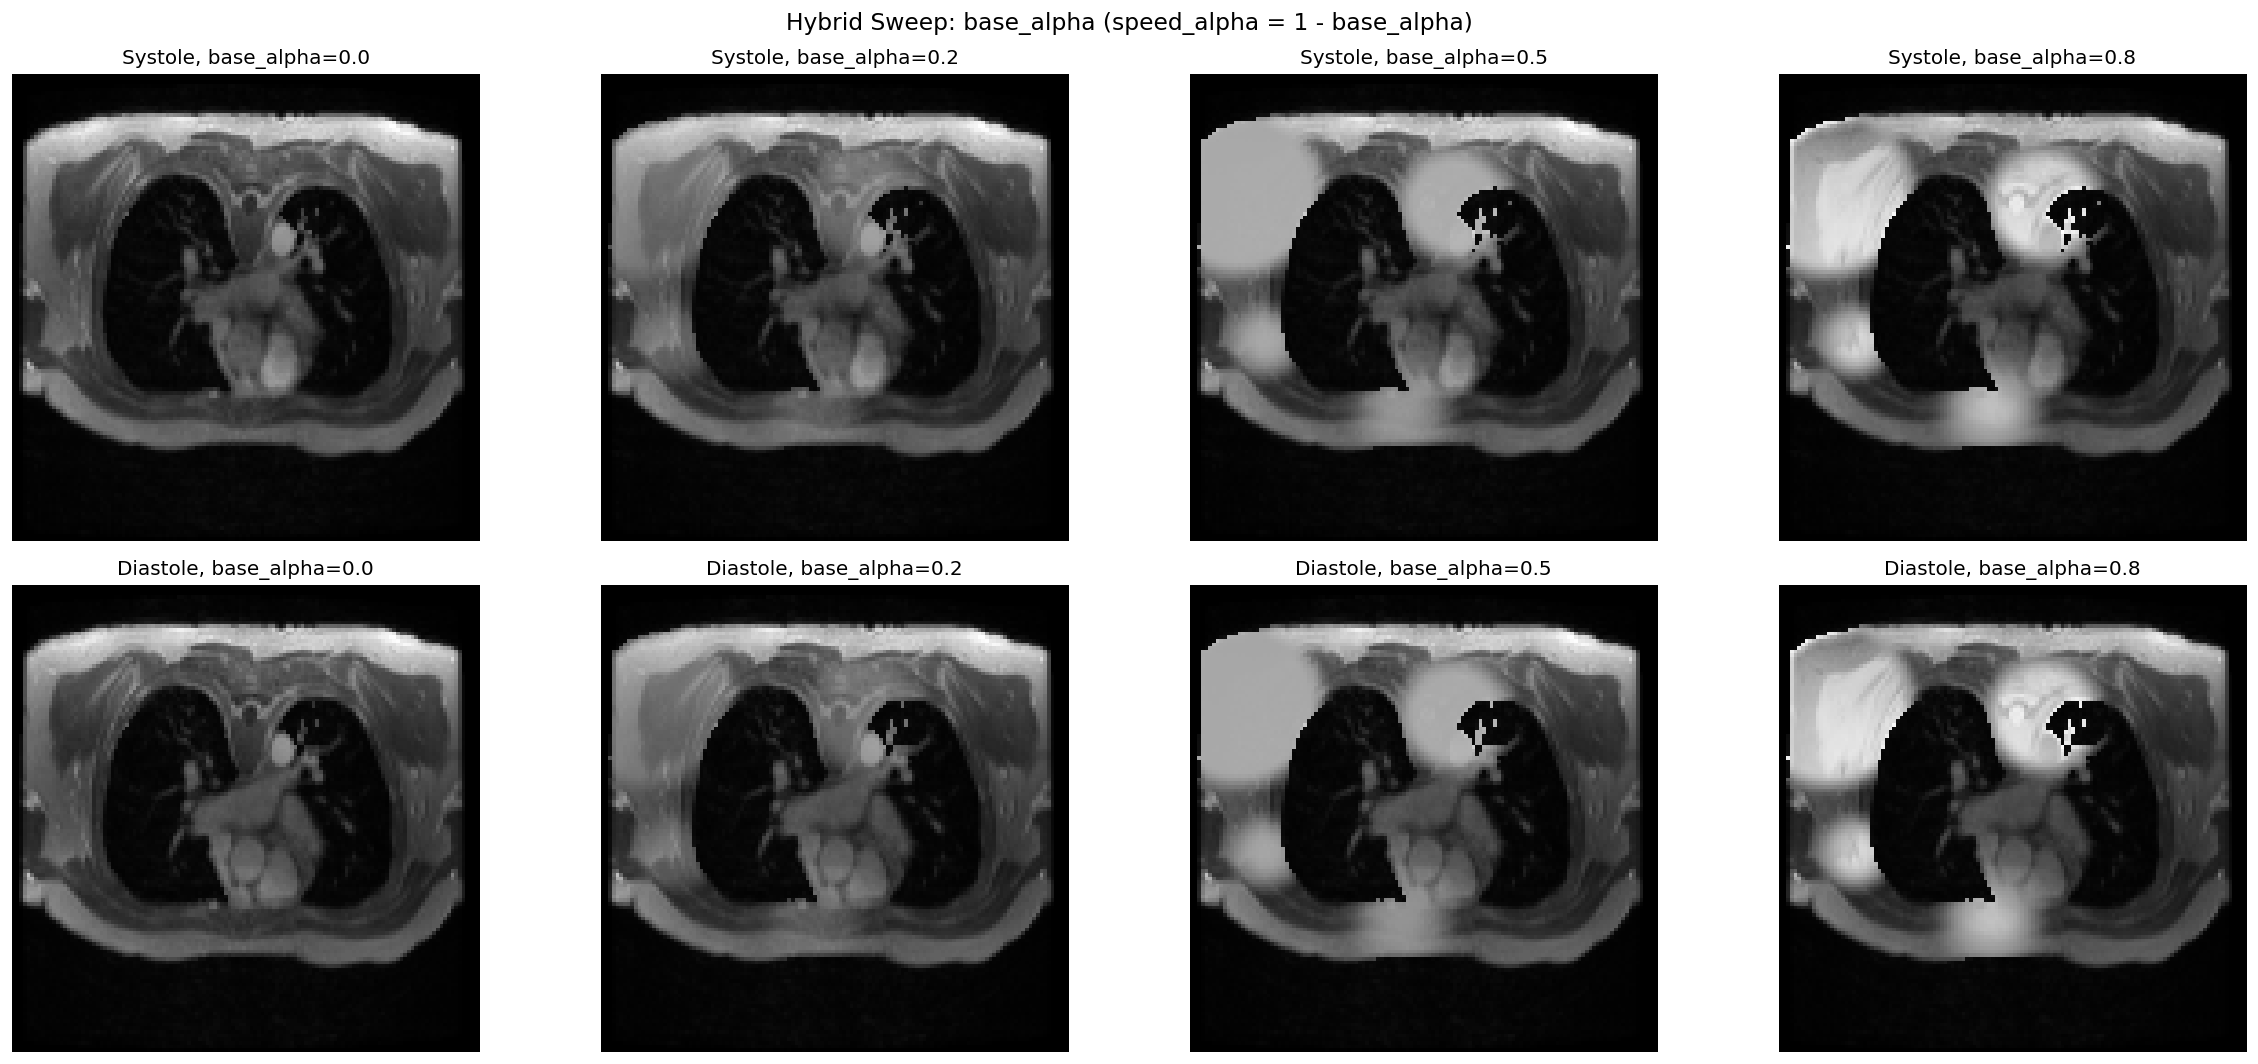

In [41]:
# Sweep base_alpha to see how much background inversion we want
base_alphas = [0.0, 0.2, 0.5, 0.8]

fig, axes = plt.subplots(2, len(base_alphas), figsize=(5 * len(base_alphas), 9))
for j, ba in enumerate(base_alphas):
    random.seed(42)
    res_s, _, _ = apply_speed_weighted_sphere_inversion(
        mag_sys, max_speed, num_spheres_range=(4, 6), radius_range=(15, 35),
        base_alpha=ba, speed_alpha_scale=1.0 - ba, speed_cap=max_speed.max()
    )
    random.seed(42)
    res_d, _, _ = apply_speed_weighted_sphere_inversion(
        mag_dia, max_speed, num_spheres_range=(4, 6), radius_range=(15, 35),
        base_alpha=ba, speed_alpha_scale=1.0 - ba, speed_cap=max_speed.max()
    )
    axes[0, j].imshow(res_s[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[0, j].set_title(f'Systole, base_alpha={ba}')
    axes[1, j].imshow(res_d[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
    axes[1, j].set_title(f'Diastole, base_alpha={ba}')

for ax in axes.flat:
    ax.axis('off')
plt.suptitle('Hybrid Sweep: base_alpha (speed_alpha = 1 - base_alpha)', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Side-by-Side Comparison

All approaches in one figure for both cardiac phases.

In [42]:
# Generate all augmentations with the same seed for fair comparison
results = {}

for phase, mag, speed_tp in [
    ('systole', mag_sys, speed_sys),
    ('diastole', mag_dia, speed_dia),
]:
    random.seed(42)
    r_single, _ = apply_single_sphere_inversion(mag, radius_range=(25, 50), alpha=1.0)

    random.seed(42)
    r_multi, _ = apply_multi_sphere_inversion(
        mag, num_spheres_range=(4, 6), radius_range=(12, 28), alpha=1.0
    )

    r_speed_thr, _ = speed_threshold_inversion(
        mag, speed_tp, threshold_fraction=0.15, alpha=1.0
    )

    r_speed_soft, _ = speed_soft_alpha_inversion(
        mag, speed_tp, speed_cap=speed_sys.max(), alpha_scale=1.0
    )

    r_agg_thr, _ = speed_threshold_inversion(
        mag, max_speed, threshold_fraction=0.15, alpha=1.0
    )

    r_agg_soft, _ = speed_soft_alpha_inversion(
        mag, max_speed, speed_cap=max_speed.max(), alpha_scale=1.0
    )

    random.seed(42)
    r_hybrid, _, _ = apply_speed_weighted_sphere_inversion(
        mag, max_speed, num_spheres_range=(4, 6), radius_range=(15, 35),
        base_alpha=0.3, speed_alpha_scale=0.7, speed_cap=max_speed.max()
    )

    results[phase] = {
        'original': mag,
        'single_sphere': r_single,
        'multi_sphere': r_multi,
        'speed_thr': r_speed_thr,
        'speed_soft': r_speed_soft,
        'agg_thr': r_agg_thr,
        'agg_soft': r_agg_soft,
        'hybrid': r_hybrid,
    }

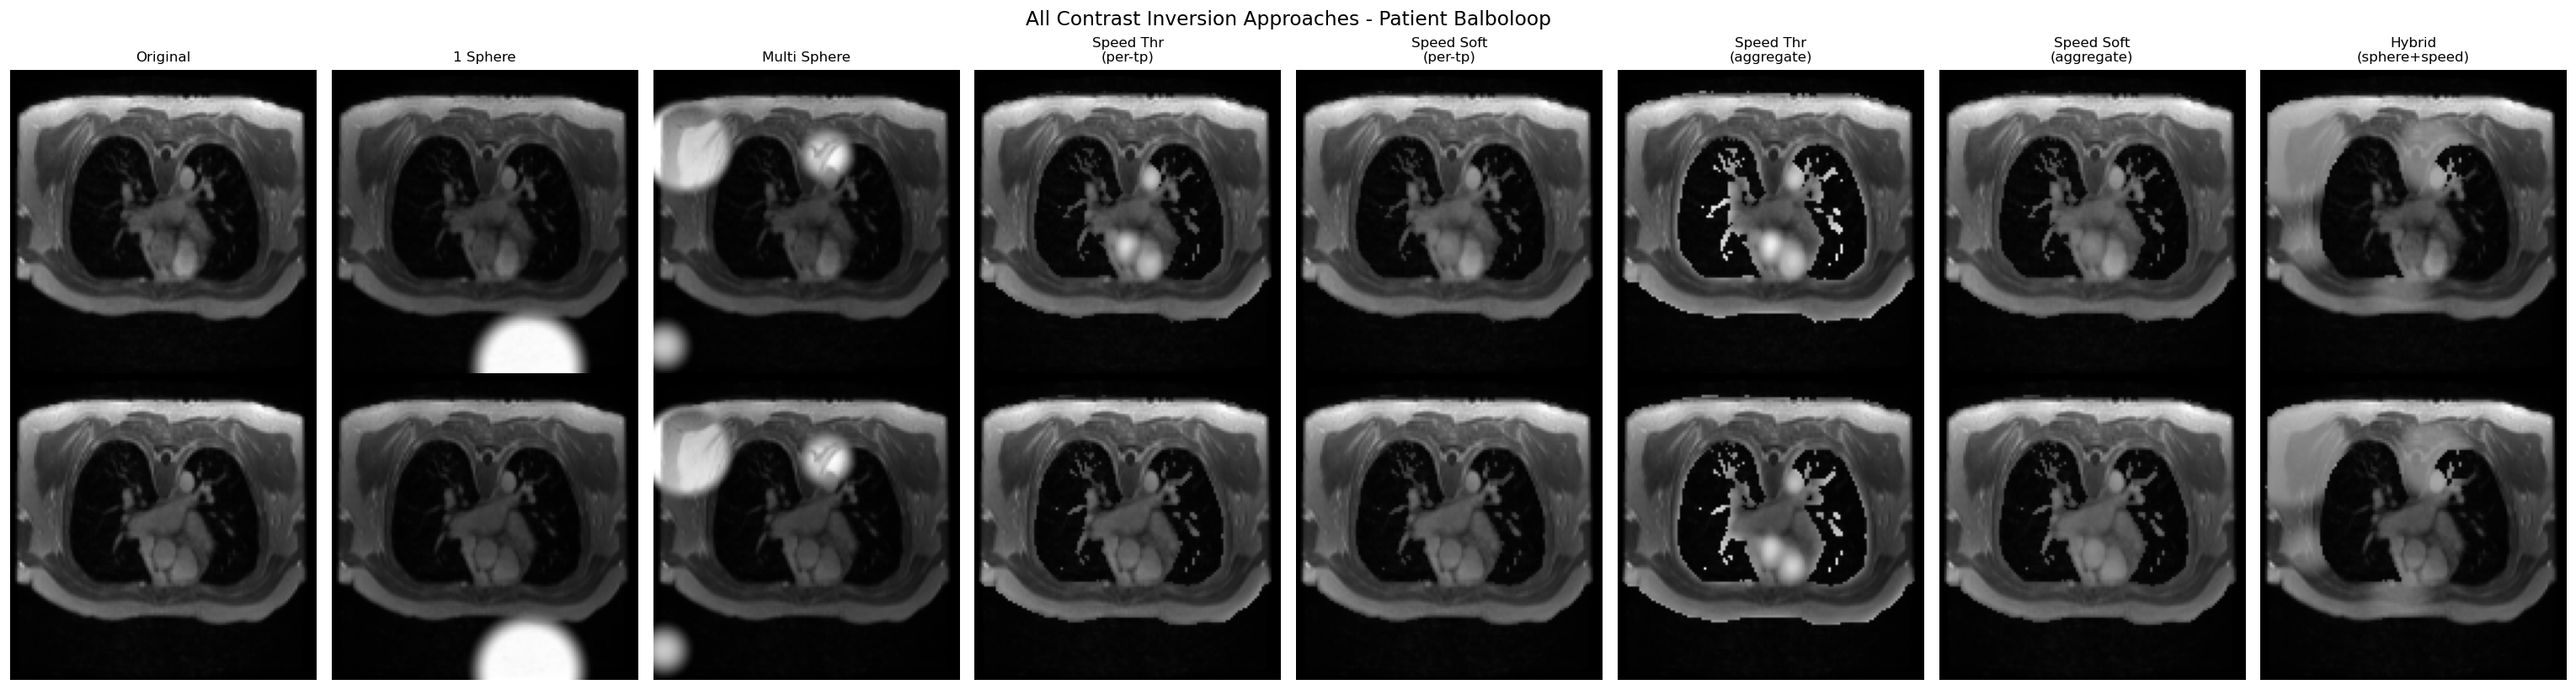

In [43]:
labels = [
    ('original', 'Original'),
    ('single_sphere', '1 Sphere'),
    ('multi_sphere', 'Multi Sphere'),
    ('speed_thr', 'Speed Thr\n(per-tp)'),
    ('speed_soft', 'Speed Soft\n(per-tp)'),
    ('agg_thr', 'Speed Thr\n(aggregate)'),
    ('agg_soft', 'Speed Soft\n(aggregate)'),
    ('hybrid', 'Hybrid\n(sphere+speed)'),
]

fig, axes = plt.subplots(2, len(labels), figsize=(3.2 * len(labels), 7))
for row, phase in enumerate(['systole', 'diastole']):
    for j, (key, title) in enumerate(labels):
        img = results[phase][key]
        axes[row, j].imshow(img[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
        if row == 0:
            axes[row, j].set_title(title, fontsize=10)
        axes[row, j].axis('off')
    axes[row, 0].set_ylabel('Systole' if row == 0 else 'Diastole',
                            fontsize=12, rotation=90, labelpad=10)

plt.suptitle(f'All Contrast Inversion Approaches - Patient {PATIENT_ID}', fontsize=14)
plt.tight_layout()
plt.show()

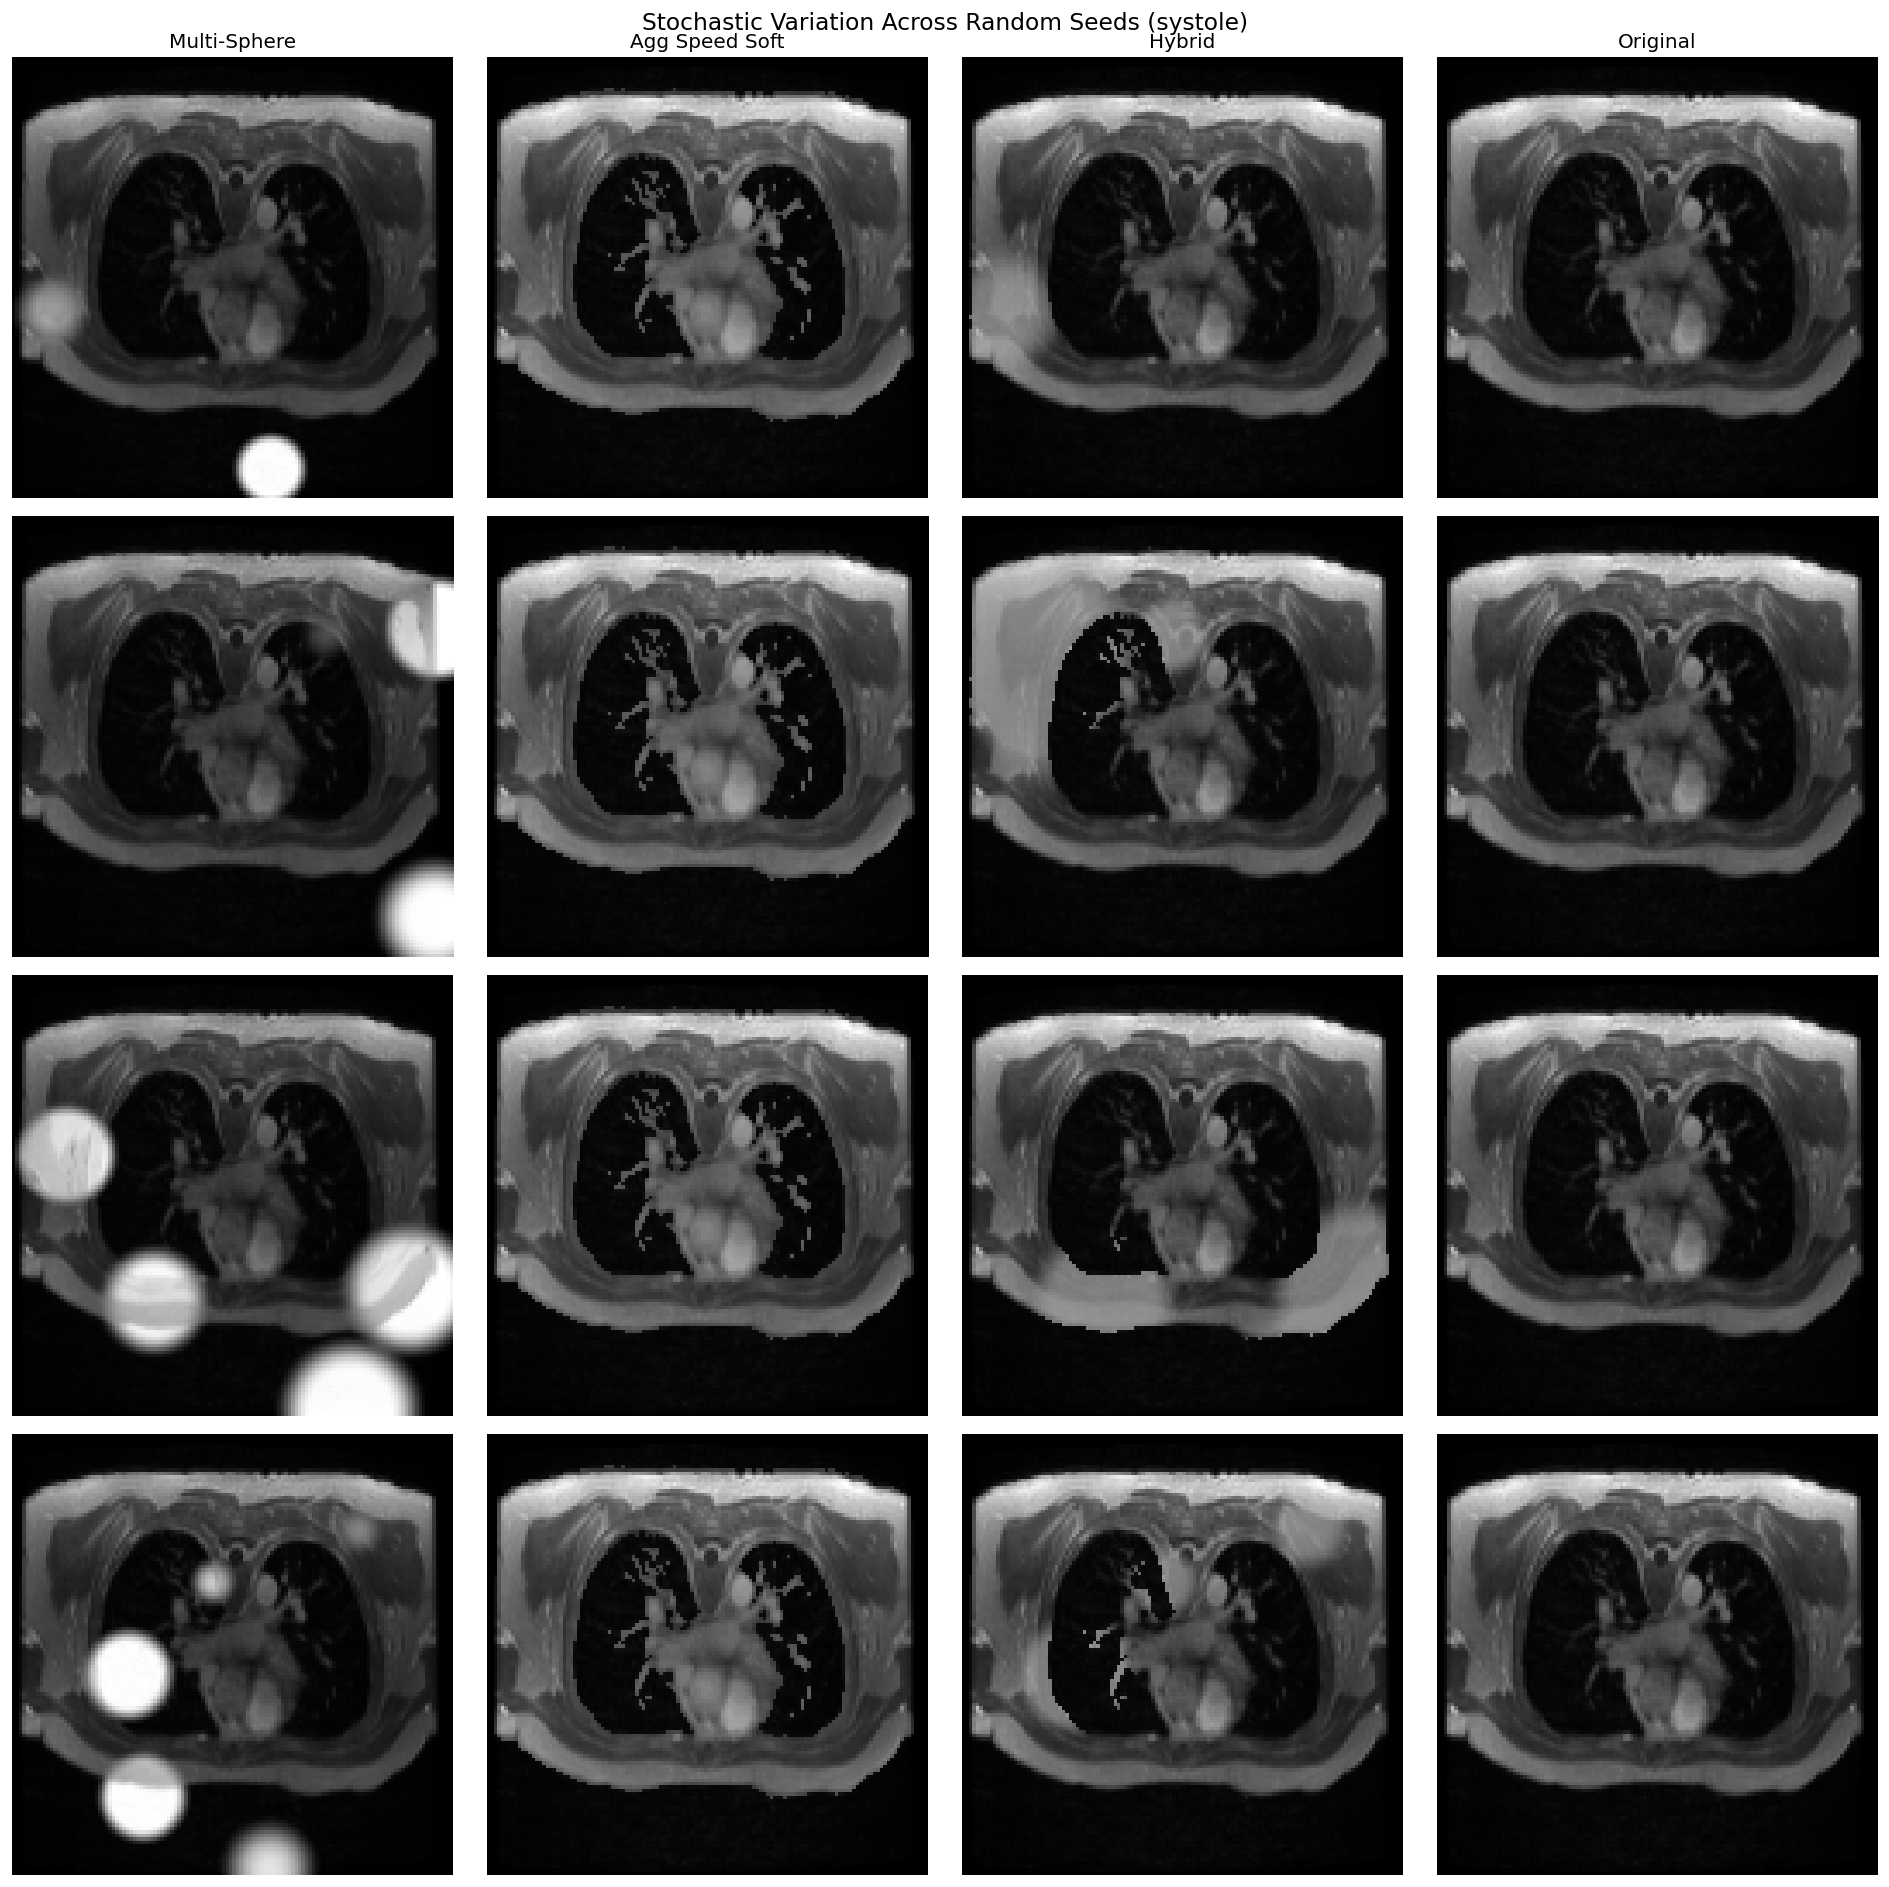

In [44]:
# Multiple random samples to see stochastic variation
n_samples = 4

fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
col_titles = ['Multi-Sphere', 'Agg Speed Soft', 'Hybrid', 'Original']

for i in range(n_samples):
    seed = i * 17 + 7

    random.seed(seed)
    r_ms, _ = apply_multi_sphere_inversion(
        mag_sys, num_spheres_range=(3, 7), radius_range=(12, 28), alpha=1.0
    )

    r_as, _ = speed_soft_alpha_inversion(
        mag_sys, max_speed, speed_cap=max_speed.max(), alpha_scale=1.0
    )

    random.seed(seed)
    r_hy, _, _ = apply_speed_weighted_sphere_inversion(
        mag_sys, max_speed, num_spheres_range=(4, 6), radius_range=(15, 35),
        base_alpha=0.3, speed_alpha_scale=0.7, speed_cap=max_speed.max()
    )

    for j, (img, title) in enumerate([
        (r_ms, col_titles[0]),
        (r_as, col_titles[1]),
        (r_hy, col_titles[2]),
        (mag_sys, col_titles[3]),
    ]):
        axes[i, j].imshow(img[0, :, :, AX_SLICE].T, cmap='gray', origin='lower')
        if i == 0:
            axes[i, j].set_title(title, fontsize=12)
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(f'Sample {i+1}', fontsize=11, rotation=90, labelpad=10)

plt.suptitle('Stochastic Variation Across Random Seeds (systole)', fontsize=14)
plt.tight_layout()
plt.show()